# EDIS 8100 · Week 2 · Exploring Learning Data

### Mapping the Learning Analytics Landscape and Theoretical Lenses

*Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia*

---

We will work through this notebook together in class, in the hour after the discussion block and
the break. Nothing from it is collected and nothing in it is graded, so there is no submission to
prepare.

If Python is new to you, that is the expected starting point here. Every cell already contains
working code, and there is no expectation that you write code from scratch today or in any week of
this course. Coding skill is not assessed anywhere in this seminar. Your attention is better spent
on what the code does to the data and on what the output might mean.

Questions are welcome at any point, including questions about a single line of code. Red error
text is normal and is part of how everyone works with notebooks.

### What I hope you leave with

1. A sense of how `groupby` changes a clickstream from one grain to another, and how
   `merge` combines two tables on a shared column. These two operations are the main technical
   content of today's hour.
2. After each data step, ask: Who is still included, who is no longer included, and does that matter?
3. Learn to read a scatterplot by separating what the graph actually shows from what we might be tempted to conclude from it.
4. Use the claim ladder from feature → indicator → construct to think about the gap between what is recorded in the data and what we actually care about theoretically.
5. Recognize that choices made during data preparation, even something like changing the axis scale, can change how we interpret the data.

None of these is a coding objective.

## What an export looks like

Today the data is real and it is institutional: enrollment records and daily click
counts from a course that ran at a UK distance-teaching university, involving people who studied.

Real institutional data is often messy. In this dataset, some students have no recorded clicks, some activity appears before the course begins, some values are missing or inconsistently labeled, and the same course appears in two different presentations. Today, we will use these examples to see how data structure and data preparation decisions can affect an analysis.

## How to work through this notebook

- Run cells **top to bottom**. Click a cell, then press **Shift + Enter**.
- If something breaks, `Runtime > Restart session and run all` fixes almost everything.
- Cells marked **Your turn** already contain a working value. You can run the whole notebook
  without editing anything and no output will be missing.
- The section marked **Going further** near the end is optional.

### The route for today

| | Sections | What it is for |
|---|---|---|
| **CORE, about 55 to 60 minutes** | Where this data came from, Setup, 1, 2a to 2e, 3, 3b, 4, 5, 5b, 6 | Provenance, grain, irregularities in the export, `groupby`, the enrollments with no recorded activity, the claim ladder, the join, and the first scatterplot of activity against coursework |
| **IF TIME** | 7, 8 | The log scale and a different Pearson r, then the enrollments the line fits worst |
| **EXPLORE LATER** | 9, Your turn 1, Going further, Appendix | Timing across the module, the cleaning switches, the partial correlation, the other year, and which clicks count |

**If you work in R, SPSS, or Stata, or have not written code before,** you might find it useful to
read the code the way you read a methods section: you are checking what was done to the data, not
memorizing syntax. Two patterns cover most of what we use. Square brackets after a table, as in
`df[df.score > 50]`, select a subset, like `subset()` or a filter. A line ending in `.mean()`,
`.sum()`, or `.value_counts()` summarizes, like `aggregate()` or a frequency table. When a line
does not make sense, please ask.

## Where this data came from

**Dataset.** The Open University Learning Analytics Dataset (OULAD), restricted to module **BBB**
and its two presentations, **2013J** and **2014J**. A *presentation* is one running of a module,
the way EDIS 8100 Fall 2026 is one running of EDIS 8100.

| | |
|---|---|
| **What** | Enrollment records, daily click counts, and assessment scores for module BBB at the UK Open University |
| **Who collected it** | The university's own teaching systems, as a by-product of running an online Virtual Learning Environment, then anonymized and published by its analytics team |
| **When** | Two presentations of the module, 2013J and 2014J |
| **License** | CC BY 4.0. Free to use, share, and adapt, with attribution |
| **Citation** | Kuzilek, J., Hlosta, M., & Zdrahal, Z. (2017). Open University Learning Analytics dataset. *Scientific Data, 4*, 170171. |

**What anonymization removed.** Names have been removed; students are identified by integers.
Calendar dates have been removed; every date is a **day number counted from the first day of the
module**, which is why we are about to see negative dates. Home addresses have been removed, and in
their place is `imd_band`, the decile of the UK Index of Multiple Deprivation for the small area a
student lives in, an area-level measure that describes a neighborhood and not a person. The module
itself is identified only as BBB.

## Setup

**Run the cell below.** It downloads this week's six files from the course dataset repository.

In [23]:
# SETUP CELL. Downloads this week's data and sets the plotting defaults.
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Default matplotlib look plus a faint grid.
plt.style.use('default')
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.dpi'] = 100

BASE = 'https://raw.githubusercontent.com/HakeoungLee/edis8100-datasets/main/oulad-bbb'

FILES = {
    'student_info':         ('studentInfo.csv',         'one enrollment: who signed up, and how it ended'),
    'student_vle':          ('studentVle.csv.gz',       'one student, one resource, one day: the clickstream'),
    'student_assessment':   ('studentAssessment.csv',   'one submitted assessment: the score'),
    'assessments':          ('assessments.csv',         'one assessment: its type, due day, and weight'),
    'student_registration': ('studentRegistration.csv', 'one enrollment: when they registered, when they left'),
    'vle':                  ('vle.csv',                 'one resource in the course website'),
}

tables = {}
try:
    for key, (filename, _) in FILES.items():
        tables[key] = pd.read_csv(f'{BASE}/{filename}')
except Exception as err:
    print('=' * 74)
    print('The data did not download, so nothing below this cell will work yet.')
    print()
    print('This notebook reads six files from the course dataset repository:')
    print('    HakeoungLee/edis8100-datasets, folder oulad-bbb')
    print(f'    {BASE}')
    print()
    print('The usual cause is no internet connection in this runtime. Check your')
    print('connection, then use Runtime > Restart session and run all. If the repository')
    print('itself is unreachable, please let Dr. Lee know and send the link above.')
    print()
    print(f'Technical detail: {type(err).__name__}: {err}')
    print('=' * 74)
    raise SystemExit('Download failed. The message above explains what to do.') from None

student_info         = tables['student_info']
student_vle          = tables['student_vle']
student_assessment   = tables['student_assessment']
assessments          = tables['assessments']
student_registration = tables['student_registration']
vle                  = tables['vle']

print('Six files arrived from HakeoungLee/edis8100-datasets (folder oulad-bbb).')
print()
total_rows = 0
for key, (filename, grain) in FILES.items():
    df = tables[key]
    total_rows += len(df)
    print(f'  {filename:<26} {len(df):>7,} rows x {df.shape[1]:>2} cols   one row is {grain}')
print()
print(f'  {"TOTAL":<26} {total_rows:>7,} rows')
print()
print('Module:', student_info['code_module'].unique().tolist(),
      '   Presentations:', sorted(student_info['code_presentation'].unique().tolist()))
print('Real, published, CC BY 4.0 data. Kuzilek, Hlosta, and Zdrahal (2017).')

Six files arrived from HakeoungLee/edis8100-datasets (folder oulad-bbb).

  studentInfo.csv              4,529 rows x 12 cols   one row is one enrollment: who signed up, and how it ended
  studentVle.csv.gz          891,062 rows x  6 cols   one row is one student, one resource, one day: the clickstream
  studentAssessment.csv       21,783 rows x  5 cols   one row is one submitted assessment: the score
  assessments.csv                 18 rows x  6 cols   one row is one assessment: its type, due day, and weight
  studentRegistration.csv      4,529 rows x  5 cols   one row is one enrollment: when they registered, when they left
  vle.csv                        528 rows x  6 cols   one row is one resource in the course website

  TOTAL                      922,449 rows

Module: ['BBB']    Presentations: ['2013J', '2014J']
Real, published, CC BY 4.0 data. Kuzilek, Hlosta, and Zdrahal (2017).


## 1. Meet the tables

Three of those six files matter today, and they have three different origins.

- `studentVle` is a **log**. One row says: on day *d*, student *s* clicked resource *r* this many
  times.
- `studentAssessment` is a **measurement**. One row per submitted assessment, produced by an
  instrument somebody built and scored against a rubric.
- `studentInfo` is an **administrative record**. One row per enrollment, assembled by a registry
  for funding, reporting, and compliance.

The **grain** of a file, meaning what one row is, is worth establishing before anything else.

**Run the cell below.**

In [45]:
print('studentInfo: one row per ENROLLMENT (a student in a presentation)')
display(student_info.head(3))

print('studentVle: one row per STUDENT x RESOURCE x DAY')
display(student_vle.head(3))

print('studentAssessment: one row per SUBMITTED ASSESSMENT')
display(student_assessment.head(3))

print('Rows are not students. These counts differ:')
print('  studentInfo rows (enrollments) :', f'{len(student_info):,}')
print('  distinct id_student values     :', f"{student_info['id_student'].nunique():,}")
print('  studentVle rows                :', f'{len(student_vle):,}')
print('  total clicks in studentVle     :', f"{student_vle['sum_click'].sum():,}")

studentInfo: one row per ENROLLMENT (a student in a presentation)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,BBB,2013J,23632,F,East Anglian Region,A Level or Equivalent,40-50%,0-35,0,60,N,Withdrawn
1,BBB,2013J,23798,M,Wales,A Level or Equivalent,50-60%,0-35,0,60,N,Distinction
2,BBB,2013J,25629,F,Scotland,Lower Than A Level,20-30%,0-35,0,120,N,Withdrawn


studentVle: one row per STUDENT x RESOURCE x DAY


,code_module,code_presentation,id_student,id_site,date,sum_click
0,BBB,2013J,560773,704206,-23,1
1,BBB,2013J,560773,704205,-23,1
2,BBB,2013J,560773,704204,-23,1


studentAssessment: one row per SUBMITTED ASSESSMENT


,id_assessment,id_student,date_submitted,is_banked,score
0,14996,23798,18,0,90.0
1,14996,27759,18,0,61.0
2,14996,30091,24,0,80.0


Rows are not students. These counts differ:
  studentInfo rows (enrollments) : 4,529
  distinct id_student values     : 4,482
  studentVle rows                : 891,062
  total clicks in studentVle     : 3,052,400


**Let's look at the output.**

- What did a student have to do for a `studentVle` row to appear? What could a student do in this
  course that would leave no row at all?
- `studentInfo` has 4,529 rows and 4,482 distinct students. Before scrolling on, you might write
  down your best guess for why.

*Connecting to the readings.* Baker and Siemens (2014) describe educational data mining and
learning analytics as two traditions that grew up around traces like these, and that handle the
gap between a recorded number and an educational idea differently. One tends to work bottom up
from the features toward automated discovery; the other tends to keep a person responsible for the
construct and for asking whether an indicator measures what its name claims.

## 2. What an export actually looks like when it arrives

Four things in this download will produce a wrong answer if nobody looks at them.

### 2a. Two runs of the module under one name

`code_presentation` takes two values. 2013J and 2014J are two different runs of module BBB, a year
apart, and, as we will see shortly, with different assessment structures.

Some students appear in **both** presentations. In this dataset the same person can therefore
contribute more than one enrollment record. Grouping only by `id_student` can merge distinct course
attempts into one record, and the clicks of two separate attempts would be added together into a
single history that no student actually had.

The unit of analysis here is an **enrollment**, a student in a presentation, rather than simply a
person.

**Run the cell below.**

In [25]:
print('Enrollments per presentation:')
print(student_info['code_presentation'].value_counts().sort_index().to_string())
print()

n_rows     = len(student_info)
n_students = student_info['id_student'].nunique()
n_repeat   = n_rows - n_students
print(f'{n_rows:,} enrollment rows but only {n_students:,} distinct students.')
print(f'{n_repeat} students took this module twice, once in each presentation.')
print()

example_id = 151917
print(f'Student {example_id}, both attempts:')
display(student_info[student_info['id_student'] == example_id]
        [['id_student', 'code_presentation', 'num_of_prev_attempts',
          'studied_credits', 'final_result']])

clicks_both = (student_vle[student_vle['id_student'] == example_id]
               .groupby('code_presentation')['sum_click'].sum())
print('Their clicks, kept separate:')
print(clicks_both.to_string())
print(f'Their clicks, added together across both presentations: {clicks_both.sum():,}')
print()
print(f'A groupby on id_student alone reports one student with {clicks_both.sum():,} '
      'clicks who both failed and passed.')

print()
n_prev = int((student_info['num_of_prev_attempts'] > 0).sum())
dup_rows = student_info[student_info.duplicated('id_student', keep=False)]
already = int((dup_rows.loc[dup_rows['code_presentation'] == '2013J',
                            'num_of_prev_attempts'] > 0).sum())
print(f'Rows recording at least one earlier attempt at this module: {n_prev} of {len(student_info):,}')
print(f'Of the {n_repeat} students with two rows here, the 2013J row was already a repeat for {already}.')


Enrollments per presentation:
code_presentation
2013J    2237
2014J    2292

4,529 enrollment rows but only 4,482 distinct students.
47 students took this module twice, once in each presentation.

Student 151917, both attempts:


,id_student,code_presentation,num_of_prev_attempts,studied_credits,final_result
71,151917,2013J,3,60,Fail
2296,151917,2014J,4,60,Pass


Their clicks, kept separate:
code_presentation
2013J    909
2014J    713
Their clicks, added together across both presentations: 1,622

A groupby on id_student alone reports one student with 1,622 clicks who both failed and passed.

Rows recording at least one earlier attempt at this module: 589 of 4,529
Of the 47 students with two rows here, the 2013J row was already a repeat for 11.


**Let's look at the output.**

**The decision.** For the rest of this notebook the unit of analysis is the
**enrollment**, not the student, and the join key is the pair `(id_student, code_presentation)`.
The student above appears twice because these were two separate enrollments, and averaging them
would describe neither one accurately.

**What this choice affects.** Across the whole file, 47 students have two rows each, so 47 of the
4,529 rows repeat a student who is already counted once. For 36 of those 47 the later row is a
second attempt; for the other 11 the 2013J row was itself already a repeat, because
`num_of_prev_attempts` was already above zero in that row.

**What the file cannot show.** Across all 4,529 rows, 589 record at least one earlier attempt at
this module. Only 47 of those repeats appear here as a duplicated student, because the earlier
attempts happened in presentations this download does not contain. The duplication visible in this
file is a small part of the repeat enrollment that actually occurred.

**Where the dependency matters and where it does not.** It matters whenever rows are treated as
independent students. Section 2e restricts the analysis to a single presentation, and inside one
presentation every `id_student` appears exactly once, so the analysis that follows is not affected
by it. The optional Your turn 2 pools the two years into one number, which reintroduces the
dependency.

### 2b. Activity before the course starts

`date` in `studentVle` is a day number counted from the first day of the module, because calendar
dates were removed to protect the students. Day 0 is day one of the course.

Negative numbers are therefore not corrupt. They are recorded clicks on the course website before
the course opens.

We will keep the pre-start clicks as **recorded activity**. Whether that activity represents
engagement is a separate interpretive question, and Section 4 introduces the vocabulary for it.

**Run the cell below.**

In [26]:
d = student_vle['date']
print(f'date runs from {d.min()} to {d.max()}    (day 0 = first day of the module)')

pre = student_vle[student_vle['date'] < 0]
print(f'Rows recorded BEFORE day 0 : {len(pre):,} of {len(student_vle):,} '
      f'({100 * len(pre) / len(student_vle):.1f}%)')
print(f'Distinct students doing it : {pre["id_student"].nunique():,}')
print()

reg = student_registration['date_registration']
print(f'Registration day: earliest {reg.min():.0f}, median {reg.median():.0f}, latest {reg.max():.0f}')
print(f'Enrollments registered before day 0 : {(reg < 0).sum():,} of {len(student_registration):,}')
print(f'Enrollments with a blank registration day: {reg.isna().sum()}')

print()
print('Earliest logged day in each presentation.')
print('No recorded activity appears before these days; the file does not tell us why.')
print(student_vle.groupby('code_presentation')['date'].min().to_string())


date runs from -23 to 268    (day 0 = first day of the module)
Rows recorded BEFORE day 0 : 46,884 of 891,062 (5.3%)
Distinct students doing it : 2,739

Registration day: earliest -198, median -57, latest 44
Enrollments registered before day 0 : 4,452 of 4,529
Enrollments with a blank registration day: 3

Earliest logged day in each presentation.
No recorded activity appears before these days; the file does not tell us why.
code_presentation
2013J   -23
2014J    -9


**Let's look at the output.**

**The decision.** We keep the pre-start clicks. Visiting the site before the course opens is a form of
engagement, and it is arguably more voluntary than most of the activity recorded later, so
dropping these rows would lower the activity totals of exactly the students who did it, with
nothing in the output to indicate that.

**What this choice affects, and by how much.** Activity totals now cover windows of unequal
length, so "total clicks" is a count rather than a rate, and two students compared on it may have
had different amounts of time in which to click. The 2013J log contains no row earlier than
day -23 and the 2014J log none earlier than day -9. No rows were recorded before those days,
whatever a student's registration date said. Registration runs from 198 days early to 44 days
late, but the extra pre-start window this produces in the log is at most about three weeks, not
six months. Your turn 1 lets you reverse this decision and see how small the resulting change is.

### 2c. A blank column, and one label typed out of pattern

`imd_band` records the deprivation decile of the small area a student lives in. It should have ten
categories, each written the same way.

A label typed out of pattern is a data entry inconsistency we can see and repair. A blank is
different: missingness may itself be patterned, so it is worth examining. This file does not tell us why any particular value is absent, and we will not guess.

**Run the cell below** and see how many categories there are and how they are spelled.

In [46]:
print('imd_band, exactly as it arrived:')
print(student_info['imd_band'].value_counts(dropna=False).to_string())
print()
print(f"Distinct labels, blanks not counted : {student_info['imd_band'].nunique()}")
print(f"Rows where imd_band is blank        : {student_info['imd_band'].isna().sum()}")
print()
print('Ten deciles, ten labels. Nine of them include a percent sign. One does not.')
print('Sorted the way pandas sorts text:')
print(sorted(student_info['imd_band'].dropna().unique().tolist()))
print()

# What happens to somebody who writes out the ten labels the sensible way?
expected = [f'{i}-{i + 10}%' for i in range(0, 100, 10)]
print('The ten labels a careful analyst would write by hand:')
print(expected)

unmatched = ~student_info['imd_band'].isin(expected)
odd_label = int((student_info['imd_band'] == '10-20').sum())
odd_people = int(student_info.loc[student_info['imd_band'] == '10-20', 'id_student'].nunique())
blank     = int(student_info['imd_band'].isna().sum())
print()
print(f'Rows that list does NOT match : {int(unmatched.sum()):,} of {len(student_info):,} '
      f'({100 * unmatched.mean():.1f}%)')
print(f'  because the band is blank   : {blank}')
print(f'  because it says "10-20"     : {odd_label}   <- one missing percent sign')
print()
print(f'Mapping deciles to numbers with that list turns {odd_label} enrollments, '
      f'covering {odd_people} students, into missing values,')
print('all from the same band. No error is raised and no warning is printed.')

imd_band, exactly as it arrived:
imd_band
0-10%      591
20-30%     566
10-20      557
30-40%     495
40-50%     474
50-60%     449
60-70%     412
70-80%     353
80-90%     335
90-100%    268
NaN         29

Distinct labels, blanks not counted : 10
Rows where imd_band is blank        : 29

Ten deciles, ten labels. Nine of them include a percent sign. One does not.
Sorted the way pandas sorts text:
['0-10%', '10-20', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']

The ten labels a careful analyst would write by hand:
['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']

Rows that list does NOT match : 586 of 4,529 (12.9%)
  because the band is blank   : 29
  because it says "10-20"     : 557   <- one missing percent sign

Mapping deciles to numbers with that list turns 557 enrollments, covering 550 students, into missing values,
all from the same band. No error is raised and no warning is printed.


**Let's look at the output.**

**The decision.** `imd_band` is not part of today's analysis, so we will not repair it
here. It is worth seeing because it shows what the problem looks like: a socioeconomic variable,
the variable an equity audit would use, arriving with a blank on 29 enrollment records and one
band typed without its percent sign.

**What this choice affects, if you do use the column.** This kind of problem produces no warning,
which is why it has to be checked for directly. As soon as those labels are converted to numbers
with a hand-written list, or filtered with a `str.endswith('%')`, the 557 enrollments in the
second-most-deprived band, 550 distinct students, are excluded from the analysis and nothing in
the output reports it. If the 29 blanks are dropped as well, the analysis has also excluded
students whose deprivation was never recorded, and "not recorded" is rarely random either.

**What the column does and does not record.** `imd_band` is a decile of the UK Index of Multiple
Deprivation for the small area attached to a student's address at one point in time. It describes
a neighborhood, not a household and not a person. Two students in the same band may have had
entirely different circumstances, and a student's band may have changed during the module without
the file recording the change.

### 2d. Enrollments with no recorded activity

The clickstream can only contain students whose clicks were logged. Finding the others means
starting from the roster and looking for which enrollments are **missing** from the log.

**Run the cell below.**

In [47]:
KEY = ['id_student', 'code_presentation']

any_activity = student_vle[KEY].drop_duplicates()
roster = student_info.merge(any_activity.assign(clicked=True), on=KEY, how='left')
roster['clicked'] = roster['clicked'].fillna(False).astype(bool)

n_silent = int((~roster['clicked']).sum())
print(f'Enrollments in studentInfo        : {len(roster):,}')
print(f'Enrollments with at least 1 click : {int(roster["clicked"].sum()):,}')
print(f'Enrollments with NO clicks ever   : {n_silent:,}  '
      f'({100 * n_silent / len(roster):.1f}%, about 1 in {len(roster) / n_silent:.1f})')
print()

print('How every enrollment ended:')
print(student_info['final_result'].value_counts().to_string())
print()
print('Percent of the whole cohort:')
print((100 * student_info['final_result'].value_counts(normalize=True)).round(1).to_string())

Enrollments in studentInfo        : 4,529
Enrollments with at least 1 click : 3,791
Enrollments with NO clicks ever   : 738  (16.3%, about 1 in 6.1)

How every enrollment ended:
final_result
Pass           1868
Withdrawn      1393
Fail            912
Distinction     356

Percent of the whole cohort:
final_result
Pass           41.2
Withdrawn      30.8
Fail           20.1
Distinction     7.9


/tmp/ipykernel_17915/238507285.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  roster['clicked'] = roster['clicked'].fillna(False).astype(bool)


**Let's look at the output.**

About one enrollment in six never registers a single click, and close to a third of the cohort
ends in `Withdrawn`. This is a distance-learning module, so those numbers describe the population
it enrolls rather than anything about the individual students in it. They also mean that the
students an early-warning system is most concerned with are the students with the least recorded
activity.

### 2e. The scoping decision

We are going to analyze **one presentation, 2013J**, and state that scope every time we report a
number.

Why not both? Because they are not the same course. In the table the next cell prints, 2013J was
assessed with six tutor-marked assignments and five computer-marked ones, while 2014J was assessed
with five tutor-marked assignments and no computer-marked ones at all, and the first of those five
carried a weight of zero. Both years end with an exam. Pooling the two would average across two
different assessment structures and report the result as a single finding.

**What this choice affects.** It removes half the data, and it rules out asking whether a pattern
replicates across years. The optional Your turn 2 restores 2014J so you can see how much the
answer depends on which year is analyzed.

**Run the cell below.**

In [29]:
PRESENTATION = '2013J'

print('Assessment structure, side by side:')
display(assessments.pivot_table(index='assessment_type', columns='code_presentation',
                                values='id_assessment', aggfunc='count')
                   .fillna(0).astype(int))

print('Every assessment, its due day (day number), and its weight:')
display(assessments.sort_values(['code_presentation', 'date'])
        [['code_presentation', 'assessment_type', 'date', 'weight']]
        .reset_index(drop=True))

enroll  = student_info[student_info['code_presentation'] == PRESENTATION].copy()
vle_log = student_vle[student_vle['code_presentation'] == PRESENTATION].copy()

print()
print(f'Scoped to {PRESENTATION}:')
print(f'  enrollments      : {len(enroll):,}')
print(f'  clickstream rows : {len(vle_log):,}')
print(f'  total clicks     : {vle_log["sum_click"].sum():,}')
print(f'  day range        : {vle_log["date"].min()} to {vle_log["date"].max()}')

Assessment structure, side by side:


code_presentation,2013J,2014J
assessment_type,,
CMA,5,0
Exam,1,1
TMA,6,5


Every assessment, its due day (day number), and its weight:


,code_presentation,assessment_type,date,weight
0,2013J,TMA,19.0,5.0
1,2013J,TMA,47.0,18.0
2,2013J,CMA,54.0,1.0
3,2013J,CMA,96.0,1.0
4,2013J,TMA,96.0,18.0
5,2013J,CMA,131.0,1.0
6,2013J,TMA,131.0,18.0
7,2013J,CMA,166.0,1.0
8,2013J,TMA,166.0,18.0
9,2013J,CMA,208.0,1.0



Scoped to 2013J:
  enrollments      : 2,237
  clickstream rows : 452,638
  total clicks     : 1,378,656
  day range        : -23 to 268


## 3. Aggregating with `groupby`

The clickstream is at a finer grain than almost any question we want to ask. Our questions are
about students; the file records one row per student, per resource, per day. `groupby` is the tool
that moves data from one grain to another.

`vle_log.groupby('id_student')` says: *split the table into one group per student.* Then we say
what to compute on each group. Two things at once here:

- `sum_click` **summed**, which gives total clicks: how much activity there was.
- `date` counted for **distinct** values, which gives active days: how many separate days that
  activity was spread across.

Those are two different definitions of activity, and they will not always rank students the same
way.

**Run the cell below.**

In [30]:
activity = (
    vle_log.groupby('id_student')
           .agg(total_clicks=('sum_click', 'sum'),
                active_days=('date', 'nunique'))
           .reset_index()
)

print(f'activity now has one row per student who clicked: {activity.shape[0]:,} rows')
display(activity.head())

print('Total clicks per student:')
print(activity['total_clicks'].describe().round(1).to_string())
print()
print(f"median  {activity['total_clicks'].median():,.0f} clicks")
print(f"maximum {activity['total_clicks'].max():,.0f} clicks")
print(f"The busiest student generated "
      f"{activity['total_clicks'].max() / activity['total_clicks'].median():.0f} times the median.")
print()
print(f'Enrollments in the roster                  : {len(enroll):,}')
print(f'Students in the activity table             : {len(activity):,}')
print(f'Enrollments missing from the activity table: {len(enroll) - len(activity):,}')
print('A groupby summarizes only the students who have rows in the log. Students with no')
print('rows do not appear in its output, so you have to account for them separately.')

activity now has one row per student who clicked: 1,870 rows


,id_student,total_clicks,active_days
0,23798,590,77
1,27759,366,46
2,30091,1332,64
3,31014,531,47
4,31849,1179,80


Total clicks per student:
count     1870.0
mean       737.2
std       1289.5
min          1.0
25%        148.2
50%        386.0
75%        817.2
max      16440.0

median  386 clicks
maximum 16,440 clicks
The busiest student generated 43 times the median.

Enrollments in the roster                  : 2,237
Students in the activity table             : 1,870
Enrollments missing from the activity table: 367
A groupby summarizes only the students who have rows in the log. Students with no
rows do not appear in its output, so you have to account for them separately.


**Let's look at the output.** The median student generated a few hundred clicks; the busiest
generated over sixteen thousand. That gap is not a data error. Behavioral trace data is usually
**heavy tailed**, meaning that a small number of people account for a large share of the total.

The next cell draws two histograms side by side. The left one plots clicks as they are. The right
one plots the same students on a **log scale**, where each step along the axis is a multiplication
rather than an addition, so 10, 100, and 1,000 sit at even intervals. The students and the clicks
are the same in both panels, and only the axis differs.

Later in the notebook, the choice between these two axes changes an estimate by a factor of nearly
two.

**Run the cell below.**

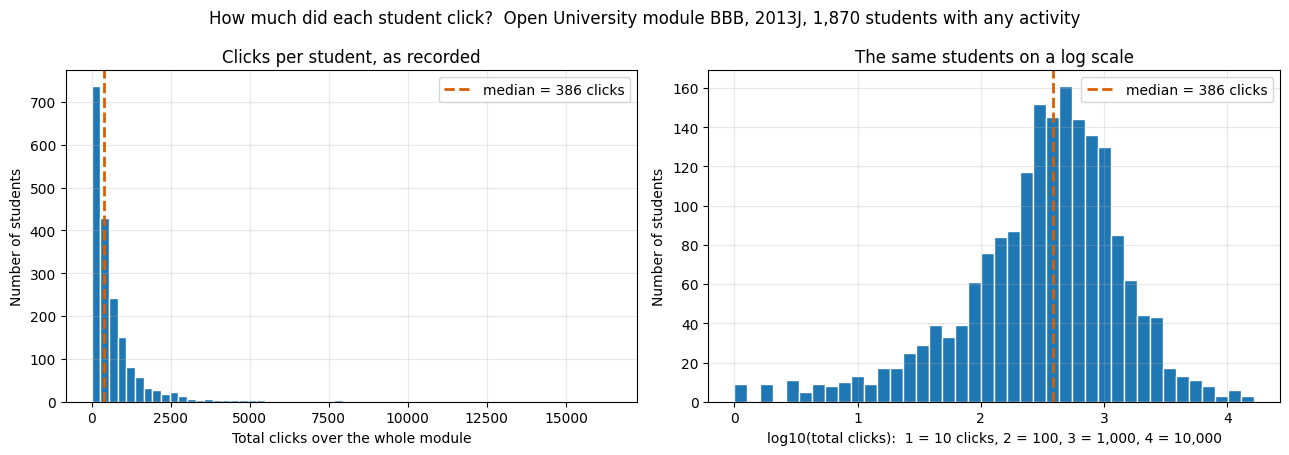

Not on either chart: 367 enrollments with no recorded clicks.
The log of zero is undefined, so the log panel cannot display a count of zero clicks.
The data cannot tell us whether those enrollments studied away from the platform,
never opened it, or used it in a way this log does not record.


In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

med = activity['total_clicks'].median()

ax1.hist(activity['total_clicks'], bins=60, color='#1f77b4', edgecolor='white')
ax1.axvline(med, color='#d95f02', linestyle='--', linewidth=2,
            label=f'median = {med:,.0f} clicks')
ax1.set_title('Clicks per student, as recorded')
ax1.set_xlabel('Total clicks over the whole module')
ax1.set_ylabel('Number of students')
ax1.legend()

ax2.hist(np.log10(activity['total_clicks']), bins=40, color='#1f77b4', edgecolor='white')
ax2.axvline(np.log10(med), color='#d95f02', linestyle='--', linewidth=2,
            label=f'median = {med:,.0f} clicks')
ax2.set_title('The same students on a log scale')
ax2.set_xlabel('log10(total clicks):  1 = 10 clicks, 2 = 100, 3 = 1,000, 4 = 10,000')
ax2.set_ylabel('Number of students')
ax2.legend()

fig.suptitle(f'How much did each student click?  Open University module BBB, {PRESENTATION}, '
             f'{len(activity):,} students with any activity', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Not on either chart: {len(enroll) - len(activity):,} enrollments with no recorded clicks.')
print('The log of zero is undefined, so the log panel cannot display a count of zero clicks.')
print('The data cannot tell us whether those enrollments studied away from the platform,')
print('never opened it, or used it in a way this log does not record.')

### Let's discuss

1. The tail on the right of the first panel represents students who actually produced those
   counts. Please describe two different students who could have produced a count that far out,
   one whose count you would read as good news and one whose count you would read as a warning
   sign. What would you need to know to distinguish the two?
2. The two panels contain the same information. Which one would you show a program director, and
   what might each one lead them to conclude?
3. The line printed underneath the charts reports that some enrolled students appear on neither
   panel. How would you report a median click count when a sixth of the cohort is excluded from
   it?

### 3b. The enrollments with no recorded activity

These enrollments are not spread evenly across the cohort. The data cannot tell us what these
students did, because this file records clicks on one website and nothing else. What we can do is
compare them against the one column that records how each enrollment ended.

The next chart describes what the virtual learning environment **recorded**, not what the students
did. "No recorded clicks" means the log holds no rows for that enrollment. Studying that leaves no
trace in this log is one of several possibilities the file cannot distinguish between.

**Run the cell below.**

/tmp/ipykernel_17915/15948754.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  enroll_flagged['clicked'] = enroll_flagged['clicked'].fillna(False).astype(bool)


,enrollments,clicked,never_clicked,pct_never_clicked
final_result,,,,
Distinction,176,176,0,0.0
Pass,896,896,0,0.0
Fail,521,472,49,9.4
Withdrawn,644,326,318,49.4


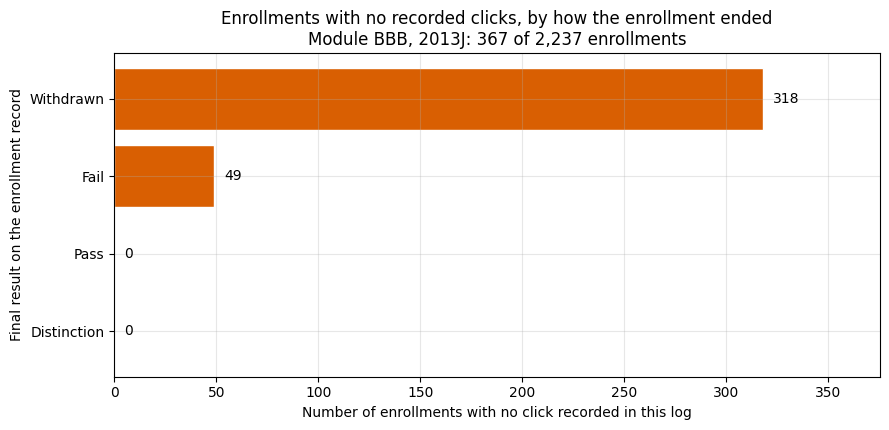

Of the 644 withdrawn enrollments, 318 (49.4%) have no click recorded.
Of the 896 passes and 176 distinctions, 0 have no click recorded.


In [32]:
enroll_flagged = enroll.merge(activity[['id_student']].assign(clicked=True),
                              on='id_student', how='left')
enroll_flagged['clicked'] = enroll_flagged['clicked'].fillna(False).astype(bool)

silent = enroll_flagged[~enroll_flagged['clicked']]
order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']

summary = (enroll_flagged.groupby('final_result')['clicked']
           .agg(enrollments='size', clicked='sum')
           .reindex(order))
summary['never_clicked'] = summary['enrollments'] - summary['clicked']
summary['pct_never_clicked'] = (100 * summary['never_clicked'] / summary['enrollments']).round(1)
display(summary)

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(order, summary['never_clicked'].values, color='#d95f02', edgecolor='white')
for i, v in enumerate(summary['never_clicked'].values):
    ax.text(v + 5, i, f'{v:,}', va='center', fontsize=10)
ax.set_title('Enrollments with no recorded clicks, by how the enrollment ended\n'
             f'Module BBB, {PRESENTATION}: {len(silent):,} of {len(enroll):,} enrollments')
ax.set_xlabel('Number of enrollments with no click recorded in this log')
ax.set_ylabel('Final result on the enrollment record')
ax.set_xlim(0, max(summary['never_clicked'].max() * 1.18, 10))
plt.tight_layout()
plt.show()

print(f'Of the {int(summary.loc["Withdrawn", "enrollments"]):,} withdrawn enrollments, '
      f'{int(summary.loc["Withdrawn", "never_clicked"]):,} '
      f'({summary.loc["Withdrawn", "pct_never_clicked"]:.1f}%) have no click recorded.')
print(f'Of the {int(summary.loc["Pass", "enrollments"]):,} passes and '
      f'{int(summary.loc["Distinction", "enrollments"]):,} distinctions, '
      f'{int(summary.loc["Pass", "never_clicked"] + summary.loc["Distinction", "never_clicked"])} '
      f'have no click recorded.')

**Let's look at the output.** Of the 644 withdrawn enrollments in 2013J, 318 have no click
recorded at all. Of the 896 passes and 176 distinctions, none are missing from the log.

Please keep three things separate here:

| | |
|---|---|
| **What the data directly show** | 367 of the 2,237 enrollments in 2013J have no row in the clickstream. 318 of those ended in `Withdrawn`, which is 49.4 percent of the 644 withdrawals. No enrollment ending in `Pass` or `Distinction` is missing from the log. |
| **A plausible interpretation** | Some of these enrollments may represent people who registered and never began, and others may represent people who studied in ways this log does not record. |
| **What this file cannot establish** | Which of those it is for any given enrollment, since the file holds no record of study away from the platform, of when someone stopped, or of why. |

### Let's discuss

1. Nearly half of the withdrawn enrollments have no click recorded. Before proposing an
   explanation about the students themselves, please work through three other levels.
   **The instrument:** what would somebody have to do for a row to appear here, and what kinds of
   studying leave no row at all? **The setting:** what might a distance university's registration
   calendar make likely in the first weeks of a module, and what would you need to read to find
   out? **The circumstances:** these are adults studying at a distance, they registered a median
   of about eight weeks before the module opened, and what else was going on in their lives is not
   a column in this file. If an explanation about the student still seems necessary after those
   three, please write that one as well, and then count how many of the four explanations are
   about something other than the student.
2. An early-warning system reads the clickstream. What does it actually know about these
   enrollments on day 14, and what is it treating as information when the log holds no record at
   all?
3. Correlating activity with achievement requires students who have both. Every enrollment on this
   chart has neither. Before continuing, please predict which final results will be excluded from
   the analysis, and whether the finding that remains describes the course or only the students
   who stayed.

## 4. The claim ladder: feature, indicator, construct

We name this idea in Week 2 so that we can refer back to it in Week 3, Week 6, and Week 7.

`total_clicks` is a number. Any sentence that interprets it makes a claim that goes beyond the
number itself.

| Rung | What it is | Today's example | How much argument it needs |
|---|---|---|---|
| **Feature** | Something the system recorded that can be counted directly. | `total_clicks = 909` for student 151917 in 2013J. | Almost none. It is arithmetic. |
| **Indicator** | A feature somebody has **argued** stands in for something educational. | "Total clicks is an indicator of how engaged a student is with the module." | A lot. This is where the argument has to be made. |
| **Construct** | The thing you actually care about. Theory defines it. No column contains it. | Engagement. Self-regulated learning. Understanding. | It has a literature, and that literature does not agree. |

Before a number is even a feature, somebody decided that it existed: that a page load counts as a
click, that a click before day 0 counts at all, that a student who never appears in the log is a
person rather than an absence. **The recording decision comes before the
feature, below the bottom rung of the ladder.**

**A practice to keep for the rest of the course:** when you make a claim, say which rung it belongs
to. "Student 151917 generated 909 clicks in 2013J" is a feature claim and needs no argument.
"Student 151917 was disengaged" is a construct claim and needs evidence.

*Connecting to the readings.* Nathan and Sawyer (2014) describe learning as deep conceptual
understanding built through activity in context, an account that does not allow learning to be
defined by whatever is easiest to capture. Baker and Siemens (2014) are useful alongside them
for naming what you are doing when you move from a feature to an indicator.

### A line to write now

The cell below is a text cell, so you can double-click it and type in it. Please finish these three
sentences:

- The feature I have is ...
- I am proposing to treat it as an indicator of ...
- The construct I actually care about is ..., and one thing this feature will miss about it is ...

*(Your answer here. Double-click this cell to type in it.)*

- The feature I have is
- I am proposing to treat it as an indicator of
- The construct I actually care about is

## 5. The other table, then the join

Comparing activity with achievement requires achievement at the same grain: one number per student.

`studentAssessment` has no `code_presentation` column. It records only `id_assessment`. The first
step is therefore to look each assessment up in the `assessments` table, which holds the
presentation, the type, the due day, and the weight. That is what a **lookup join** does, and
skipping it is how submissions from the two presentations end up combined in one analysis.

The next few lines make four judgment calls:

1. We keep the assessments with a **recorded score** and drop the small number with a blank score,
   rather than treating a blank as a zero. A blank could be an ungraded submission or an
   administrative gap; recording it as a zero would assert that the student failed.
2. We set aside rows flagged **`is_banked`**. OULAD documents this column as a result transferred
   from a previous presentation. A transferred score was not necessarily earned during the
   presentation we are analyzing, so pairing it with this presentation's click activity would
   compare a score and an activity count from different periods. The cell reports how many such
   rows there are before it removes them, and Your turn 1 asks you to add them back and see what
   changes.
3. We take the **unweighted mean** of a student's scores. The module weighted them: one
   tutor-marked assignment counted 5 percent, five counted 18 percent each, and the five
   computer-marked ones counted 1 percent each. The unweighted mean is simple, but it differs from
   the module's weighting scheme. The optional section in Going further measures the difference.
4. The exam appears in the **assessment metadata**, but exam results are not present in the
   `studentAssessment` records we are using. Our score-based analyses here therefore describe
   **recorded coursework** rather than the complete final course grade.

**Run the cell below.**

In [33]:
# Step 1: attach the presentation, type, due day, and weight to every submission.
submissions = student_assessment.merge(
    assessments[['id_assessment', 'code_presentation', 'assessment_type', 'date', 'weight']],
    on='id_assessment', how='left'
)
print(f'Submissions after the lookup join: {len(submissions):,}')
print('Submissions that failed to match an assessment: '
      f"{submissions['code_presentation'].isna().sum()}")
print()

subs = submissions[submissions['code_presentation'] == PRESENTATION].copy()
print(f'{PRESENTATION} submissions: {len(subs):,}')
print('By assessment type:')
print(subs['assessment_type'].value_counts().to_string())
print()
print('Assessment types defined for this presentation:',
      assessments[assessments['code_presentation'] == PRESENTATION]['assessment_type'].tolist())
print('The exam is defined in the assessment metadata, but no exam results appear in')
print('studentAssessment, so every score below is coursework.')
print()

# Step 2: the banked column, before we build anything on top of it.
# OULAD documents is_banked as a result transferred from a previous presentation.
n_banked = int((subs['is_banked'] == 1).sum())
print(f'Rows flagged is_banked == 1 : {n_banked:,} of {len(subs):,} '
      f'({100 * n_banked / len(subs):.2f}%)')
print(f'Students with at least one banked score : '
      f"{subs.loc[subs['is_banked'] == 1, 'id_student'].nunique():,}")
if n_banked:
    subs = subs[subs['is_banked'] == 0].copy()
    print(f'Submissions kept: {len(subs):,}')
else:
    print('There are none in this presentation, so nothing changes.')
print()

n_blank = int(subs['score'].isna().sum())
print(f'Submissions with a blank score: {n_blank}   (dropped, not zeroed)')
subs = subs.dropna(subset=['score'])

achievement = (
    subs.groupby('id_student')
        .agg(mean_score=('score', 'mean'),
             n_submissions=('score', 'size'))
        .reset_index()
)
print(f'Students with at least one scored submission: {len(achievement):,}')
display(achievement.head())
print('Scores across this presentation: mean %.1f, sd %.1f'
      % (subs['score'].mean(), subs['score'].std()))

Submissions after the lookup join: 21,783
Submissions that failed to match an assessment: 0

2013J submissions: 14,375
By assessment type:
assessment_type
TMA    7959
CMA    6416

Assessment types defined for this presentation: ['CMA', 'CMA', 'CMA', 'CMA', 'CMA', 'TMA', 'TMA', 'TMA', 'TMA', 'TMA', 'TMA', 'Exam']
The exam is defined in the assessment metadata, but no exam results appear in
studentAssessment, so every score below is coursework.

Rows flagged is_banked == 1 : 266 of 14,375 (1.85%)
Students with at least one banked score : 50
Submissions kept: 14,109

Submissions with a blank score: 9   (dropped, not zeroed)
Students with at least one scored submission: 1,682


,id_student,mean_score,n_submissions
0,23798,93.909091,11
1,27759,76.090909,11
2,30091,88.000000,10
3,31014,90.000000,5
4,31849,78.000000,11


Scores across this presentation: mean 79.0, sd 17.2


### 5b. `merge`, and a count of the enrollments left out

`merge` lines up two tables by the columns they share. An inner join creates the **complete-case
panel** this particular scatterplot needs: an enrollment appears only if it has both recorded
activity and a recorded coursework score. It is also the step where enrollments drop out of an
analysis without anything in the output saying so.

So we count before, count after, and then ask: **which enrollments were excluded, and was the
exclusion patterned?**

**Run the cell below.**

activity rows    (clicked at least once)   : 1,870
achievement rows (submitted at least once) : 1,682
panel rows       (did both)                : 1,678

  clicked but never submitted a score : 192
  submitted but no click recorded     : 4
  in the roster, in neither table     : 363

Started from 2,237 enrollments. Analyzing 1,678. Set aside 559 (25.0%).



,in the roster,in our panel,set aside,roster %,panel %
final_result,,,,,
Distinction,176,176,0,7.9,10.5
Pass,896,894,2,40.1,53.3
Fail,521,411,110,23.3,24.5
Withdrawn,644,197,447,28.8,11.7


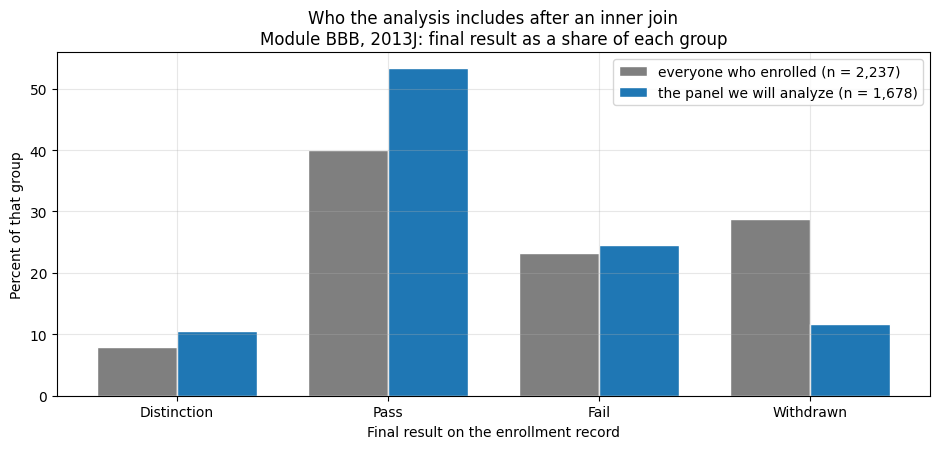

Withdrawn is 28.8% of the cohort and 11.7% of our panel.
Of the 559 enrollments we set aside: 447 withdrew, 110 failed, 2 passed.


In [34]:
panel = activity.merge(achievement, on='id_student', how='inner')
panel = panel.merge(enroll[['id_student', 'final_result']], on='id_student', how='left')

only_clicked   = len(activity) - len(panel)
only_submitted = len(achievement) - len(panel)
neither        = len(enroll) - len(panel) - only_clicked - only_submitted

print(f'activity rows    (clicked at least once)   : {len(activity):,}')
print(f'achievement rows (submitted at least once) : {len(achievement):,}')
print(f'panel rows       (did both)                : {len(panel):,}')
print()
print(f'  clicked but never submitted a score : {only_clicked:,}')
print(f'  submitted but no click recorded     : {only_submitted:,}')
print(f'  in the roster, in neither table     : {neither:,}')
print()
dropped = len(enroll) - len(panel)
print(f'Started from {len(enroll):,} enrollments. Analyzing {len(panel):,}. '
      f'Set aside {dropped:,} ({100 * dropped / len(enroll):.1f}%).')
print()

order = ['Distinction', 'Pass', 'Fail', 'Withdrawn']
roster_share = (100 * enroll['final_result'].value_counts(normalize=True)).reindex(order)
panel_share  = (100 * panel['final_result'].value_counts(normalize=True)).reindex(order)
gone = enroll[~enroll['id_student'].isin(panel['id_student'])]
gone_counts = gone['final_result'].value_counts().reindex(order).fillna(0).astype(int)

comparison = pd.DataFrame({
    'in the roster': enroll['final_result'].value_counts().reindex(order),
    'in our panel': panel['final_result'].value_counts().reindex(order),
    'set aside': gone_counts,
    'roster %': roster_share.round(1),
    'panel %': panel_share.round(1),
})
display(comparison)

x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.bar(x - 0.19, roster_share.values, width=0.38, color='#7f7f7f',
       edgecolor='white', label=f'everyone who enrolled (n = {len(enroll):,})')
ax.bar(x + 0.19, panel_share.values, width=0.38, color='#1f77b4',
       edgecolor='white', label=f'the panel we will analyze (n = {len(panel):,})')
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_title('Who the analysis includes after an inner join\n'
             f'Module BBB, {PRESENTATION}: final result as a share of each group')
ax.set_xlabel('Final result on the enrollment record')
ax.set_ylabel('Percent of that group')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Withdrawn is {roster_share['Withdrawn']:.1f}% of the cohort "
      f"and {panel_share['Withdrawn']:.1f}% of our panel.")
print(f"Of the {dropped:,} enrollments we set aside: "
      f"{gone_counts['Withdrawn']:,} withdrew, {gone_counts['Fail']:,} failed, "
      f"{gone_counts['Pass'] + gone_counts['Distinction']} passed.")

**Let's discuss.**

1. Every enrollment excluded from the analysis ended in `Fail` or `Withdrawn`. No passing student
   was excluded. In one sentence, what is our panel now a sample **of**?
2. Nothing here was done incorrectly. An inner join is the right operation for a scatterplot of
   two variables. So where exactly did the distortion enter, and what qualifying sentence has to
   appear next to every number we report from here on?
3. A vendor validates an engagement metric on a panel built this way and reports that it predicts
   success. What have they shown, and what have they not?
4. It may be worth going back to your prediction from Section 3b. Were the final result categories
   that dropped out the ones you expected?

## 6. How are recorded activity and coursework scores associated?

This plot appears in a great many dashboards. It is usually described as effort on the x axis and
outcome on the y axis. The x axis is a count of recorded clicks on a website, and calling that
effort is a claim nobody has argued for yet. Before running it, it may be useful to write down
what you expect.

The cell adds a least squares line and prints two correlations, each with an interval, because a
single coefficient is not enough to describe what is happening here.

- **Pearson `r`** ranges from -1 to 1 and summarizes the strength and direction of a **linear**
  association between two variables. On a variable as heavy tailed as click counts, a small
  Pearson `r` can mean that the two variables are weakly related, or it can mean that they are
  related in a way that is not a straight line.
- **Spearman's rho** is the same calculation done on **ranks** instead of raw values. It answers a
  weaker question: when one variable increases, does the other tend to increase? Because it uses
  only the ordering, it returns the same value whether clicks are plotted raw, logged, or square
  rooted.
- **`r` squared.** In this simple linear model, `r` squared describes the proportion of variation
  in coursework score accounted for by the linear relationship with recorded click volume in this
  analysis panel. It does not imply causation, and it is not a property of a student.
- The **95 percent interval** in square brackets comes from resampling: draw a panel the size of
  ours from our own enrollments with replacement, recompute the correlation, do that 2,000 times,
  and report the middle 95 percent of the resulting values. The bootstrap does not require the
  variables themselves to be normally distributed, but it still depends on the sampling structure
  and on the observations being appropriate units to resample.

**Run the cell below.**

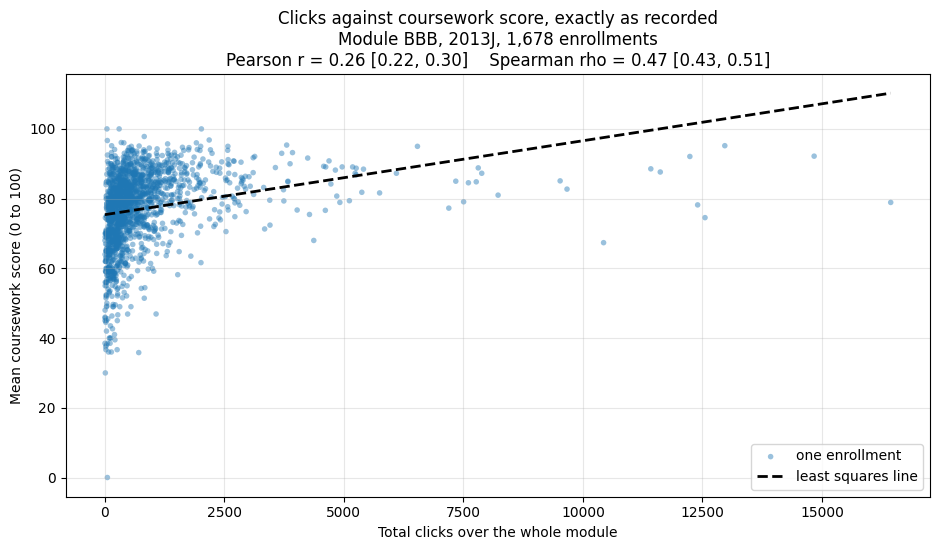

Pearson r (straight line, raw counts) = 0.259   95% interval [0.223, 0.298]
r squared                             = 0.067
   A straight line in raw clicks accounts for about 7% of the variation
   in coursework scores. The other 93% is not accounted for by that line.
Spearman rho (ranks)                  = 0.473   95% interval [0.433, 0.512]

Pearson is small because a straight line fits these points poorly. Spearman is
larger because the ordering does hold: enrollments with more recorded clicks do
tend to score higher. The intervals are narrow, so neither estimate depends much
on which enrollments happened to land in this panel. A precise estimate is not
necessarily a correct one: both still describe 1,678 enrollments that the
inner join kept. Neither number explains why, and neither describes any
individual student in this file.


In [35]:
r_raw = panel['total_clicks'].corr(panel['mean_score'])
rho = panel['total_clicks'].corr(panel['mean_score'], method='spearman')

# A 95% interval without a formula: resample the enrollments with replacement,
# recompute, repeat 2,000 times, keep the middle 95% of the answers.
def boot_ci(statistic, n, reps=2000, seed=8100):
    rng = np.random.default_rng(seed)
    vals = [statistic(rng.integers(0, n, n)) for _ in range(reps)]
    return np.percentile(vals, [2.5, 97.5])

n_panel = len(panel)
clicks_v = panel['total_clicks'].to_numpy(float)
score_v  = panel['mean_score'].to_numpy(float)
ranks    = lambda v: pd.Series(v).rank().to_numpy()

ci_raw = boot_ci(lambda s: np.corrcoef(clicks_v[s], score_v[s])[0, 1], n_panel)
ci_rho = boot_ci(lambda s: np.corrcoef(ranks(clicks_v[s]), ranks(score_v[s]))[0, 1], n_panel)

fig, ax = plt.subplots(figsize=(9.5, 5.6))
ax.scatter(panel['total_clicks'], panel['mean_score'],
           s=16, color='#1f77b4', alpha=0.45, edgecolor='none', label='one enrollment')

slope, intercept = np.polyfit(panel['total_clicks'], panel['mean_score'], 1)
xline = np.linspace(panel['total_clicks'].min(), panel['total_clicks'].max(), 100)
ax.plot(xline, slope * xline + intercept, color='#000000', linewidth=2,
        linestyle='--', label='least squares line')

ax.set_title('Clicks against coursework score, exactly as recorded\n'
             f'Module BBB, {PRESENTATION}, {len(panel):,} enrollments\n'
             f'Pearson r = {r_raw:.2f} [{ci_raw[0]:.2f}, {ci_raw[1]:.2f}]    '
             f'Spearman rho = {rho:.2f} [{ci_rho[0]:.2f}, {ci_rho[1]:.2f}]')
ax.set_xlabel('Total clicks over the whole module')
ax.set_ylabel('Mean coursework score (0 to 100)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'Pearson r (straight line, raw counts) = {r_raw:.3f}   '
      f'95% interval [{ci_raw[0]:.3f}, {ci_raw[1]:.3f}]')
print(f'r squared                             = {r_raw ** 2:.3f}')
print(f'   A straight line in raw clicks accounts for about {100 * r_raw ** 2:.0f}% of the variation')
print(f'   in coursework scores. The other {100 - 100 * r_raw ** 2:.0f}% is not accounted for by that line.')
print(f'Spearman rho (ranks)                  = {rho:.3f}   '
      f'95% interval [{ci_rho[0]:.3f}, {ci_rho[1]:.3f}]')
print()
print('Pearson is small because a straight line fits these points poorly. Spearman is')
print('larger because the ordering does hold: enrollments with more recorded clicks do')
print('tend to score higher. The intervals are narrow, so neither estimate depends much')
print('on which enrollments happened to land in this panel. A precise estimate is not')
print(f'necessarily a correct one: both still describe {n_panel:,} enrollments that the')
print('inner join kept. Neither number explains why, and neither describes any')
print('individual student in this file.')

**Let's look at the output.** Pearson `r` is 0.259 with an interval of [0.223, 0.298];
Spearman's rho on the same points is 0.473 with an interval of [0.433, 0.512]. The two coefficients
differ, and that difference is what needs to be interpreted.

What the pair supports, and what it does not:

| | |
|---|---|
| **What the data directly show** | Among the 1,678 enrollments in the panel, a straight line in raw clicks accounts for about 7 percent of the variation in coursework scores, while the rank ordering of clicks and the rank ordering of scores agree considerably more closely. |
| **A plausible interpretation** | The association between recorded activity and coursework score is monotone but not linear, so a Pearson coefficient on raw counts understates how much the two orderings have in common. |
| **What this file cannot establish** | Anything about direction or cause, and anything about the 559 enrollments that the inner join excluded and that therefore do not appear here at all. |

### Let's discuss

1. Most of the points sit close to the left edge of the x axis and a few extend far to the right.
   How does that distribution affect the least squares line?
2. Pearson came out near 0.26 and Spearman near 0.47 on the same points. What are some plausible
   reasons two coefficients computed on identical data would differ that much, and what would you
   check to decide among them? Then say what the pair supports and what it does not.
3. Most of the variation in scores is not accounted for by click volume. It may be useful to name
   three plausible sources of the rest of that variation, with at least two of them about the
   course or the measurement rather than about the students.
4. A vendor demo shows a university this chart and proposes an alert for students below the cohort
   median in activity. Using the claim ladder from Section 4, which rung does that pitch actually
   rest on, and which rung does it appear to claim?

## 7. The same observations, a different scale, a different Pearson r

The students, the scores, and the underlying click records are unchanged. What changes is how
click volume is **represented mathematically**: we analyze `log10(clicks)` rather than raw click
counts, and the Pearson correlation nearly doubles.

**Spearman's rho will not change at all.** A log is a monotone transformation, so it leaves every
enrollment's rank exactly where it was, and a rank correlation is unaffected by it. Two different
quantities are therefore involved, and they should be kept separate:

- the **rank association**, which is unchanged;
- the **linear association on the transformed scale**, which changes, because a straight line fits
  that representation better.

The next cell splits the panel into ten equal groups by click volume and shows how mean score
changes across them.

**Run the cell below.**

In [36]:
panel['decile'] = pd.qcut(panel['total_clicks'], 10, labels=False) + 1
dec = (panel.groupby('decile')
            .agg(students=('id_student', 'size'),
                 median_clicks=('total_clicks', 'median'),
                 mean_score=('mean_score', 'mean'))
            .round(1))
display(dec)

d1, d5, d10 = dec.loc[1], dec.loc[5], dec.loc[10]
print(f'From decile 1 to decile 5 : +{d5.median_clicks - d1.median_clicks:,.0f} clicks '
      f'goes with +{d5.mean_score - d1.mean_score:.1f} score points')
print(f'From decile 5 to decile 10: +{d10.median_clicks - d5.median_clicks:,.0f} clicks '
      f'goes with +{d10.mean_score - d5.mean_score:.1f} score points')
print()
print(f'{(d10.median_clicks - d5.median_clicks) / (d5.median_clicks - d1.median_clicks):.1f} '
      'times as many additional clicks, and about half as much increase in score.')
print('The relationship is not a straight line in raw clicks. It flattens as clicks rise.')
print('A log scale is the standard way to represent that kind of flattening.')

,students,median_clicks,mean_score
decile,,,
1,168,51.5,65.6
2,169,132.0,71.9
3,169,215.0,73.1
4,165,300.0,75.8
5,168,393.0,77.8
6,168,511.5,79.4
7,167,670.0,80.2
8,168,901.5,80.4
9,168,1306.5,82.9


From decile 1 to decile 5 : +342 clicks goes with +12.2 score points
From decile 5 to decile 10: +2,201 clicks goes with +6.4 score points

6.4 times as many additional clicks, and about half as much increase in score.
The relationship is not a straight line in raw clicks. It flattens as clicks rise.
A log scale is the standard way to represent that kind of flattening.


**Let's look at the output.** From decile 1 to decile 5, an extra 342 clicks at the median goes
with 11.6 more score points. From decile 5 to decile 10, an extra 2,198 clicks goes with 6.5 more.
That is about 6.4 times as many additional clicks for about half as much increase in score. The
relationship is not a straight line in clicks; it flattens as click volume rises, and a log scale
is the standard way to represent that kind of flattening.

**Run the cell below** for the two scatterplots side by side. The only difference between them is
one function call, `np.log10` applied to the x value. The two Pearson numbers are in the titles,
and the Spearman values printed underneath are identical.

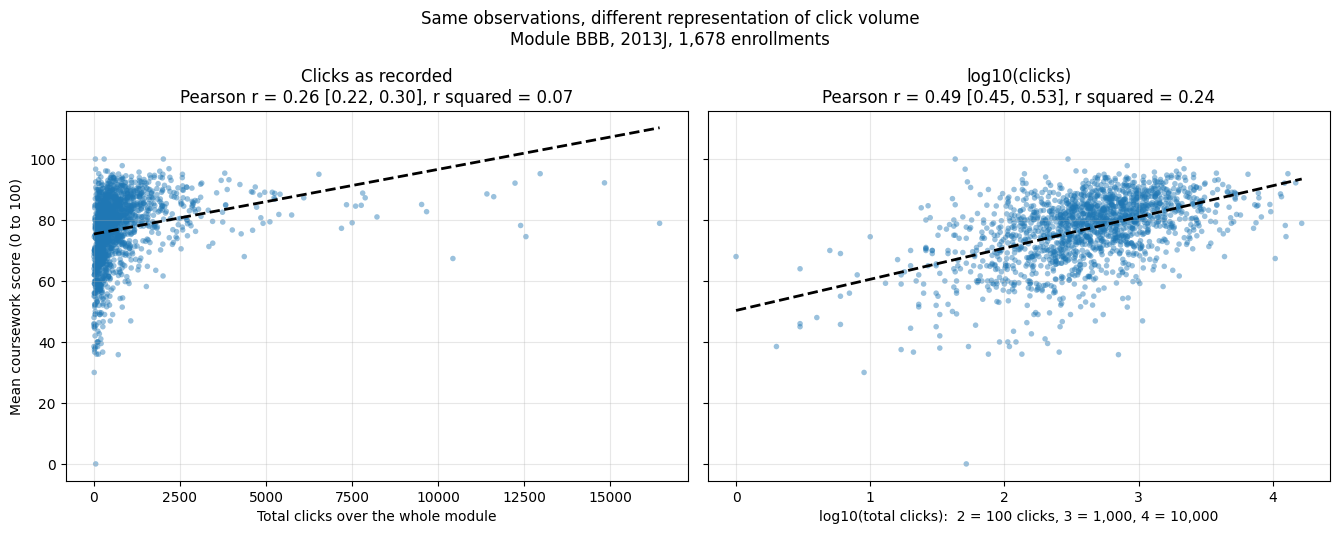

Pearson r, raw click count : 0.259   [0.223, 0.298]   (r squared 0.067)
Pearson r, log10(clicks)   : 0.489   [0.451, 0.527]   (r squared 0.239)
Difference                 : 0.230   [0.192, 0.267]
   That interval indicates that the improvement in fit holds across resamples
   of these enrollments. It does NOT indicate a stronger relationship, because
   the two correlations describe the same students and the same activity.

Spearman rho, raw click count : 0.473   [0.433, 0.512]
Spearman rho, log10(clicks)   : 0.473      <- identical, to every decimal
A log leaves every enrollment in the same rank order, so a rank correlation is
unaffected by it. The linear association on the log scale is stronger because a
straight line fits that representation better.

Reported one way: "a straight line in raw clicks accounts for 7% of the score variation."
Reported the other: "a straight line in log clicks accounts for 24%."
Both statements are true of the same 1,678 enrollments, and neither one
esti

In [37]:
panel['log_clicks'] = np.log10(panel['total_clicks'])
r_log = panel['log_clicks'].corr(panel['mean_score'])
rho_log = panel['log_clicks'].corr(panel['mean_score'], method='spearman')

logc_v = panel['log_clicks'].to_numpy(float)
ci_log = boot_ci(lambda s: np.corrcoef(logc_v[s], score_v[s])[0, 1], n_panel)
# The same resampled enrollments feed both correlations, so this is an interval on
# the difference between two numbers computed on one set of people, not on two samples.
ci_diff = boot_ci(lambda s: (np.corrcoef(logc_v[s], score_v[s])[0, 1]
                             - np.corrcoef(clicks_v[s], score_v[s])[0, 1]), n_panel)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.4), sharey=True)

for ax, xcol, title, xlabel in [
        (ax1, 'total_clicks',
         f'Clicks as recorded\nPearson r = {r_raw:.2f} [{ci_raw[0]:.2f}, {ci_raw[1]:.2f}], '
         f'r squared = {r_raw ** 2:.2f}',
         'Total clicks over the whole module'),
        (ax2, 'log_clicks',
         f'log10(clicks)\nPearson r = {r_log:.2f} [{ci_log[0]:.2f}, {ci_log[1]:.2f}], '
         f'r squared = {r_log ** 2:.2f}',
         'log10(total clicks):  2 = 100 clicks, 3 = 1,000, 4 = 10,000')]:
    ax.scatter(panel[xcol], panel['mean_score'], s=16, color='#1f77b4',
               alpha=0.45, edgecolor='none')
    s, i = np.polyfit(panel[xcol], panel['mean_score'], 1)
    xs = np.linspace(panel[xcol].min(), panel[xcol].max(), 100)
    ax.plot(xs, s * xs + i, color='#000000', linewidth=2, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel(xlabel)

ax1.set_ylabel('Mean coursework score (0 to 100)')
fig.suptitle('Same observations, different representation of click volume\n'
             f'Module BBB, {PRESENTATION}, {len(panel):,} enrollments', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Pearson r, raw click count : {r_raw:.3f}   [{ci_raw[0]:.3f}, {ci_raw[1]:.3f}]'
      f'   (r squared {r_raw ** 2:.3f})')
print(f'Pearson r, log10(clicks)   : {r_log:.3f}   [{ci_log[0]:.3f}, {ci_log[1]:.3f}]'
      f'   (r squared {r_log ** 2:.3f})')
print(f'Difference                 : {r_log - r_raw:.3f}   [{ci_diff[0]:.3f}, {ci_diff[1]:.3f}]')
print('   That interval indicates that the improvement in fit holds across resamples')
print('   of these enrollments. It does NOT indicate a stronger relationship, because')
print('   the two correlations describe the same students and the same activity.')
print()
print(f'Spearman rho, raw click count : {rho:.3f}   [{ci_rho[0]:.3f}, {ci_rho[1]:.3f}]')
print(f'Spearman rho, log10(clicks)   : {rho_log:.3f}      <- identical, to every decimal')
print('A log leaves every enrollment in the same rank order, so a rank correlation is')
print('unaffected by it. The linear association on the log scale is stronger because a')
print('straight line fits that representation better.')
print()
print(f'Reported one way: "a straight line in raw clicks accounts for {100 * r_raw ** 2:.0f}% of the score variation."')
print(f'Reported the other: "a straight line in log clicks accounts for {100 * r_log ** 2:.0f}%."')
print(f'Both statements are true of the same {len(panel):,} enrollments, and neither one')
print('estimates any causal effect of clicking.')

**Let's discuss.** Click counts are heavy tailed, and the decile table shows the movement in score
flattening, so a model that treats a step of a few hundred clicks at the bottom of the
distribution as equivalent to the same step at the top is making an assumption few people would
accept. Using a log transformation treats proportional differences in recorded click volume as
more comparable than equal absolute differences. That is a modeling decision about the
relationship between this recorded feature and the outcome, not a direct claim about how learning
itself works.

The raw version is also defensible: clicks are what the system counted, and transforming them adds
the analyst's own reasoning to what the reader is shown.

What is harder to defend is choosing between them after seeing which one gives the bigger number.

Spearman is 0.473 before the transformation and 0.473 after it, because the rank ordering is
unchanged. The linear association is stronger on the log-transformed scale because a straight line
fits that representation better. The interval on the difference, 0.230 [0.192, 0.267], indicates
that the difference is stable under this bootstrap resampling procedure. An improvement in fit
that would reproduce across a thousand resamples is still an improvement in fit rather than a
finding about students. A paper that reports the jump from 7 percent to 24 percent without
mentioning that the rank correlation did not move is not stating a falsehood, and it is allowing a
reader to conclude something the data do not support.

*Connecting to the readings.* Reich (2022) writes about studying learning at scale through
whatever traces a platform happens to keep. The analysis also runs through whatever
transformations the analyst happens to apply. Both the trace and the transformation are choices
somebody made, and neither of them is visible in a reported coefficient.

1. You are writing the results paragraph. Which numbers do you report, and what has to be reported
   alongside them so that a reader could evaluate the claim and disagree with you?
2. A colleague reports the log version with no mention of the transformation. How would you
   characterize that, and does your answer change if they are selling a product?
3. Where does the transformation sit on the claim ladder? It is not a feature and it is not a
   construct. What would you call it?
4. An interval indicates how much an estimate would vary across different samples of the same kind
   of people. What is one thing that could be wrong with a correlation that a narrow interval would
   not reveal? Section 5b printed one of them.

## 8. Low recorded click volume, high coursework score

A regression line is an average, and an average does not describe any particular student. Two
views show the enrollments the line fits poorly.

First, a summary table: the panel split into three equal groups by click volume, with the
**spread** of scores inside each group beside the average.

The click counts here are totals over the **whole module**, so nothing in this section is an
early-warning analysis. A total that includes the last week of term could not have been known in
week three. What follows describes which enrollments a whole-course activity summary classifies as
low, not a model that could have identified anyone early enough to act. Week 3 builds a prediction
correctly, using a cutoff date.

**Run the cell below.**

In [38]:
panel['tercile'] = pd.qcut(panel['total_clicks'], 3,
                           labels=['low third', 'middle third', 'high third'])

tercile_table = (
    panel.groupby('tercile', observed=True)
         .agg(students=('id_student', 'count'),
              median_clicks=('total_clicks', 'median'),
              mean_score=('mean_score', 'mean'),
              sd_of_score=('mean_score', 'std'),
              lowest_score=('mean_score', 'min'),
              highest_score=('mean_score', 'max'))
         .round(1)
)
display(tercile_table)

high_median = panel.loc[panel['tercile'] == 'high third', 'mean_score'].median()
low_group = panel[panel['tercile'] == 'low third']
n_beat = int((low_group['mean_score'] > high_median).sum())
print(f'Median score of the HIGH click third: {high_median:.1f}')
print(f'Low click students scoring above that median: {n_beat} of {len(low_group)} '
      f'({100 * n_beat / len(low_group):.1f}%)')
print(f'Difference between the low and high group means: '
      f'{tercile_table.loc["high third", "mean_score"] - tercile_table.loc["low third", "mean_score"]:.1f} points')
print(f'Spread inside the low group alone (sd): '
      f'{tercile_table.loc["low third", "sd_of_score"]:.1f} points')

,students,median_clicks,mean_score,sd_of_score,lowest_score,highest_score
tercile,,,,,,
low third,560,144.5,70.5,12.3,0.0,100.0
middle third,558,442.5,78.7,8.6,35.8,100.0
high third,560,1183.0,82.2,8.0,46.9,100.0


Median score of the HIGH click third: 83.5
Low click students scoring above that median: 68 of 560 (12.1%)
Difference between the low and high group means: 11.7 points
Spread inside the low group alone (sd): 12.3 points


**Let's look at the output.** The group means increase from the low third to the high third, so
the trend is present. Read `sd_of_score` next to those means, and compare `lowest_score` with
`highest_score` **within** any one row: the range of scores inside a single activity group is much
wider than the difference between the groups. The low third averages 70.5 and the high third 82.1,
a difference of 11.6 points, while the standard deviation inside the low third alone is 12.4. A
modest `r` describes exactly this situation: one summary line drawn across seventeen hundred
people, with individual scores spread widely around it.

The next cell identifies the enrollments with **low recorded activity and high scores**: the
bottom third of clicks and the top quarter of scores.

**Please run the cell below.**

Click cutoff (33rd percentile) : 285 clicks
Score cutoff (75th percentile) : 84.8 points
Enrollments with low clicks and high scores: 55 of 1,678
The cutoffs actually select 33.4% of the panel on clicks and 25.1% on score.
If clicks and score were unrelated, the two shares multiplied would put about 141 enrollments in that group. There are 55.
This group is smaller than that expected count. That difference is the same association
Section 6 measured.

Their median click count: 159, against 442 for the panel as a whole.

How those enrollments ended:
final_result
Distinction     9
Pass           20
Fail           14
Withdrawn      12
Withdrawn: 12 of 55 (21.8%), against 11.7% of the full
analysis panel. These are two descriptive rates. We are not testing a subgroup
difference here.

The ten highest scorers in that group:


,id_student,total_clicks,active_days,n_submissions,mean_score,final_result
0,509390,43,8,1,100.000000,Fail
1,440593,51,6,3,96.666667,Pass
2,556427,141,20,6,95.166667,Withdrawn
3,398891,203,29,11,94.090909,Pass
4,2620279,136,13,5,93.200000,Withdrawn
5,305935,53,5,2,92.500000,Fail
6,520006,213,20,11,92.272727,Distinction
7,574065,145,15,11,92.000000,Distinction
8,440765,137,23,3,92.000000,Fail
9,509258,259,7,4,91.500000,Fail


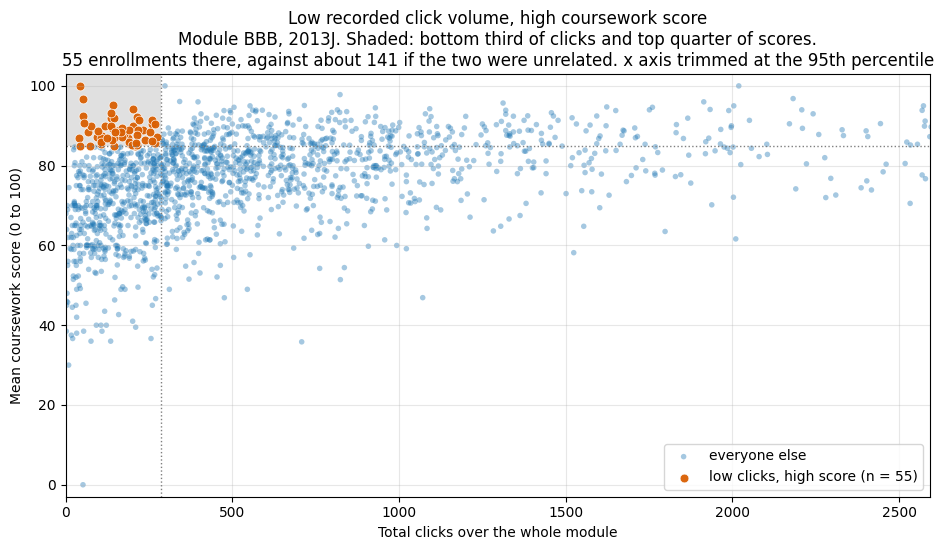

In [39]:
click_cut = panel['total_clicks'].quantile(1 / 3)
score_cut = panel['mean_score'].quantile(0.75)

corner = panel[(panel['total_clicks'] <= click_cut) & (panel['mean_score'] >= score_cut)]
# The cutoffs are percentiles, and ties mean the actual shares are not exactly
# a third and a quarter. Use the shares the cutoffs really produce.
low_share  = (panel['total_clicks'] <= click_cut).mean()
high_share = (panel['mean_score']   >= score_cut).mean()
expected   = len(panel) * low_share * high_share

print(f'Click cutoff (33rd percentile) : {click_cut:,.0f} clicks')
print(f'Score cutoff (75th percentile) : {score_cut:.1f} points')
print(f'Enrollments with low clicks and high scores: {len(corner)} of {len(panel):,}')
print(f'The cutoffs actually select {100 * low_share:.1f}% of the panel on clicks and '
      f'{100 * high_share:.1f}% on score.')
print(f'If clicks and score were unrelated, the two shares multiplied would put about {expected:.0f} '
      f'enrollments in that group. There are {len(corner)}.')
print('This group is smaller than that expected count. That difference is the same association')
print('Section 6 measured.')
print()
print(f'Their median click count: {corner["total_clicks"].median():,.0f}, '
      f'against {panel["total_clicks"].median():,.0f} for the panel as a whole.')
print()
print('How those enrollments ended:')
print(corner['final_result'].value_counts()
      .reindex(['Distinction', 'Pass', 'Fail', 'Withdrawn']).to_string())

n_wd = int((corner['final_result'] == 'Withdrawn').sum())
print(f'Withdrawn: {n_wd} of {len(corner)} ({100 * n_wd / len(corner):.1f}%), '
      f'against {100 * (panel["final_result"] == "Withdrawn").mean():.1f}% of the full')
print('analysis panel. These are two descriptive rates. We are not testing a subgroup')
print('difference here.')
print()
print('The ten highest scorers in that group:')
display(corner[['id_student', 'total_clicks', 'active_days', 'n_submissions',
                'mean_score', 'final_result']]
        .sort_values('mean_score', ascending=False).head(10).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9.5, 5.6))
x_lo, x_hi = 0, panel['total_clicks'].quantile(0.95)
y_lo, y_hi = panel['mean_score'].min() - 3, 103
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)

ax.add_patch(plt.Rectangle((x_lo, score_cut), click_cut - x_lo, y_hi - score_cut,
                           facecolor='#bbbbbb', alpha=0.45, zorder=0))
ax.axhline(score_cut, color='#7f7f7f', linewidth=1, linestyle=':')
ax.axvline(click_cut, color='#7f7f7f', linewidth=1, linestyle=':')

others = panel.drop(corner.index)
ax.scatter(others['total_clicks'], others['mean_score'], s=16, color='#1f77b4',
           alpha=0.40, edgecolor='none', label='everyone else')
ax.scatter(corner['total_clicks'], corner['mean_score'], s=40, color='#d95f02',
           alpha=0.95, edgecolor='white', linewidth=0.5,
           label=f'low clicks, high score (n = {len(corner)})')

ax.set_title('Low recorded click volume, high coursework score\n'
             f'Module BBB, {PRESENTATION}. Shaded: bottom third of clicks and top quarter of scores.\n'
             f'{len(corner)} enrollments there, against about {expected:.0f} if the two were unrelated. '
             'x axis trimmed at the 95th percentile')
ax.set_xlabel('Total clicks over the whole module')
ax.set_ylabel('Mean coursework score (0 to 100)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Let's look at the output.** Fifty-five enrollments fall inside the shaded region, several of
them with scores near the top of the cohort, at a median of 159 clicks against the panel's 442.
That is fewer than the roughly 141 that would fall there if clicks and scores were unrelated, and
it is well above zero.

| | |
|---|---|
| **What the data directly show** | 55 of the 1,678 enrollments are in the bottom third of clicks and the top quarter of coursework scores. Nine ended in `Distinction`, 20 in `Pass`, 14 in `Fail`, and 12 in `Withdrawn`. Among these 55 enrollments, 12 ended in withdrawal, against 11.7 percent of the full analysis panel. We are not testing a subgroup difference here. |
| **A plausible interpretation** | For these enrollments, recorded click volume does not correspond to whatever produced the coursework scores. |
| **What this file cannot establish** | Where the studying happened, or whether these enrollments differ in any way beyond the two columns used to select them. |

### Let's discuss

1. Three different explanations would each place an enrollment in this group: one favorable to the
   student, one concerning, and one about the **system** rather than the student. This is a
   distance-learning module, so it may be worth asking where else the studying could have
   happened.
2. A rule that labels low whole-course click volume as low engagement would classify these
   enrollments as low. What would that rule capture correctly, and what would it miss?
3. Consider the enrollment in this group with the highest coursework average. What would a
   whole-course activity summary have reported about that student, and what would it have missed?
   Week 3 builds a model that has to make this classification in advance rather than in hindsight,
   and audits it, starting with the question of what it should be called.
4. Asking the question in the other direction: the busiest third averages only a few points above
   the middle third. If more recorded activity corresponds to so small a difference in score, what
   might that indicate about the course materials, the assessment, and the platform, before it
   indicates anything about the students? What data would help distinguish among those
   explanations?
5. Baker and Siemens (2014) separate discovering structure in data from acting on it. Which of
   the two is happening when these fifty-five enrollments are identified, and which one would
   require permission?

## Your turn 1: the cleaning decisions

Every number above depends on decisions made in Section 2. In this section you make those
decisions yourself.

Each of the three settings below is a defensible position that an analyst has taken in a published
paper. Changing them and re-running changes two things: **how many students the analysis
includes**, and **what the correlation estimate becomes**.

The cell runs as written and reproduces the panel you already have, so it may be useful to run it
once before changing anything.

- `INCLUDE_PRE_START_CLICKS`: keep the clicks recorded before day 0, or set them aside because the
  exposure window is unequal?
- `MIN_SUBMISSIONS`: how many scored submissions must a student have before they count as having a
  coursework score? One is a minimal requirement; three requires more submitted work on record.
- `KEEP_WITHDRAWN`: keep enrollments that ended in withdrawal, or restrict to students who stayed?

**Please run the cell below**, then change a value and run it again.

In [40]:
# EDIT THESE FOUR VALUES. The cell runs as written.
INCLUDE_PRE_START_CLICKS = True    # True or False
MIN_SUBMISSIONS          = 1       # 1, 2, 3, ...
KEEP_WITHDRAWN           = True    # True or False
KEEP_BANKED              = False   # True or False. Section 5 sets these aside by default.

# --- nothing below needs editing ---
def build_panel(presentation='2013J', include_pre_start=True,
                min_submissions=1, keep_withdrawn=True, keep_banked=False):
    """Rebuild the whole panel under one set of cleaning decisions."""
    roster_p = student_info[student_info['code_presentation'] == presentation]
    if not keep_withdrawn:
        roster_p = roster_p[roster_p['final_result'] != 'Withdrawn']

    log = student_vle[student_vle['code_presentation'] == presentation]
    if not include_pre_start:
        log = log[log['date'] >= 0]
    act = log.groupby('id_student').agg(total_clicks=('sum_click', 'sum')).reset_index()

    sc = submissions[submissions['code_presentation'] == presentation]
    if not keep_banked:
        sc = sc[sc['is_banked'] == 0]
    sc = sc.dropna(subset=['score'])
    ach = (sc.groupby('id_student')
             .agg(mean_score=('score', 'mean'), n_submissions=('score', 'size'))
             .reset_index())
    ach = ach[ach['n_submissions'] >= min_submissions]

    return (roster_p[['id_student', 'final_result']]
            .merge(act, on='id_student', how='inner')
            .merge(ach, on='id_student', how='inner'))

p = build_panel(PRESENTATION, INCLUDE_PRE_START_CLICKS, MIN_SUBMISSIONS,
                KEEP_WITHDRAWN, KEEP_BANKED)
rr = p['total_clicks'].corr(p['mean_score'])
rl = np.log10(p['total_clicks']).corr(p['mean_score'])
rs = p['total_clicks'].corr(p['mean_score'], method='spearman')

print(f'pre-start clicks kept : {INCLUDE_PRE_START_CLICKS}')
print(f'minimum submissions   : {MIN_SUBMISSIONS}')
print(f'withdrawn kept        : {KEEP_WITHDRAWN}')
print(f'banked scores kept    : {KEEP_BANKED}')
print('-' * 60)
print(f'enrollments analyzed  : {len(p):,}   '
      f'(baseline {len(panel):,}; started from {len(enroll):,} enrolled)')
print(f'median clicks         : {p["total_clicks"].median():,.0f}')
print(f'mean coursework score : {p["mean_score"].mean():.1f}')
print(f'share withdrawn       : {100 * (p["final_result"] == "Withdrawn").mean():.1f}%')
print(f'Pearson r, raw clicks : {rr:.3f}   (baseline {r_raw:.3f})')
print(f'Pearson r, log clicks : {rl:.3f}   (baseline {r_log:.3f})')
print(f'Spearman rho          : {rs:.3f}   (baseline {rho:.3f})')
print('-' * 60)
print(f'Enrolled students excluded from the analysis: {len(enroll) - len(p):,}')

pre-start clicks kept : True
minimum submissions   : 1
withdrawn kept        : True
banked scores kept    : False
------------------------------------------------------------
enrollments analyzed  : 1,678   (baseline 1,678; started from 2,237 enrolled)
median clicks         : 442
mean coursework score : 77.1
share withdrawn       : 11.7%
Pearson r, raw clicks : 0.259   (baseline 0.259)
Pearson r, log clicks : 0.489   (baseline 0.489)
Spearman rho          : 0.473   (baseline 0.473)
------------------------------------------------------------
Enrolled students excluded from the analysis: 559


**Let's discuss.** No student's behavior changed. What changed is which students the analysis
includes, and both the sample size and the correlation estimate changed with it.

You might write one sentence naming the setting you would defend in a methods section, and one
sentence naming what a reader would need to be told about the students it excluded from the
analysis.

The pre-start setting changes the results very little, while `MIN_SUBMISSIONS` changes them a
great deal. Cleaning decisions are not equally consequential, and the only way to tell which ones
matter is to check. That check has a name in the literature: a **sensitivity analysis**.

## 9. When does the work happen?

So far we have ignored time. Every count in this notebook has treated a click on day 3 and a click
on day 200 as the same thing, and the educational interest is usually in the timing.

This module ran for months and had assignments due on known days. The next cell counts clicks per
day and marks every due date, and beside it counts how many distinct students had **recorded
activity in each complete week** of the module.

That second line counts distinct students with recorded activity in a given week. A student can
have no recorded activity one week and recorded activity the next, so it is not a count of students
who have left the module.

**Please run the cell below.**

Tutor-marked assignment due days   : [19, 47, 96, 131, 166, 208]
Computer-marked assignment due days: [54, 96, 131, 166, 208]
The exam is defined in the assessment metadata but has no results in
studentAssessment, so it contributes no due-day marker here.

Days of activity before the module opens: 11, with 63,524 clicks (4.6% of the total).
Busiest day: day 2, 19,872 clicks from 698 students.
Mean clicks per day from day 0 onward: 4,889
Mean clicks per day in the 7 days up to the first assignment (day 19): 10,662

The log ends on day 268, so module week 38 holds only 3 days.
The weekly panel below stops at week 37, the last complete week, so every point counts 7 days.
Distinct students active in module week 0  : 1,372
Distinct students active in module week 37 : 381

Weeks with more active students than the week before: 14 of 37
The five largest week-to-week increases, by week: [12, 13, 29, 23, 34]
Weeks a tutor-marked assignment was due: [2, 6, 13, 18, 23, 29]
Weekly recorded activity

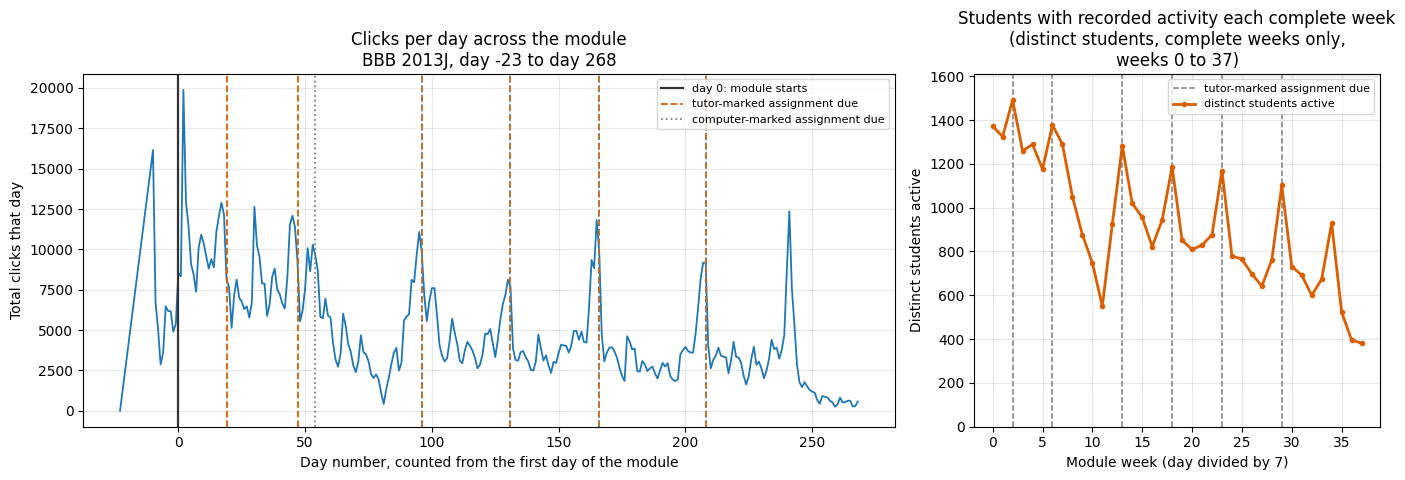

In [41]:
daily = (vle_log.groupby('date')
                .agg(clicks=('sum_click', 'sum'), students=('id_student', 'nunique'))
                .reset_index())

due = assessments[(assessments['code_presentation'] == PRESENTATION)
                  & assessments['date'].notna()]
tma_days = sorted(due[due['assessment_type'] == 'TMA']['date'].tolist())
cma_days = sorted(due[due['assessment_type'] == 'CMA']['date'].tolist())
print('Tutor-marked assignment due days   :', [int(v) for v in tma_days])
print('Computer-marked assignment due days:', [int(v) for v in cma_days])
print('The exam is defined in the assessment metadata but has no results in')
print('studentAssessment, so it contributes no due-day marker here.')
print()

pre_days = daily[daily['date'] < 0]
print(f'Days of activity before the module opens: {len(pre_days)}, '
      f'with {pre_days["clicks"].sum():,} clicks '
      f'({100 * pre_days["clicks"].sum() / daily["clicks"].sum():.1f}% of the total).')
peak = daily.loc[daily['clicks'].idxmax()]
print(f'Busiest day: day {int(peak["date"])}, {int(peak["clicks"]):,} clicks '
      f'from {int(peak["students"]):,} students.')
print(f'Mean clicks per day from day 0 onward: '
      f'{daily.loc[daily["date"] >= 0, "clicks"].mean():,.0f}')
first_due = tma_days[0]
print(f'Mean clicks per day in the 7 days up to the first assignment (day {int(first_due)}): '
      f'{daily[(daily["date"] >= first_due - 6) & (daily["date"] <= first_due)]["clicks"].mean():,.0f}')
print()

# A weekly count is only comparable across weeks that are the same length. The log ends
# on day 268, so the last bucket would hold 3 days against everyone else's 7. Drop it,
# and say so, rather than drawing a cliff the calendar put there.
last_day   = int(vle_log['date'].max())
full_weeks = (last_day + 1) // 7
print(f'The log ends on day {last_day}, so module week {full_weeks} holds only '
      f'{last_day - full_weeks * 7 + 1} days.')
print(f'The weekly panel below stops at week {full_weeks - 1}, the last complete week, '
      'so every point counts 7 days.')
weekly = (vle_log[(vle_log['date'] >= 0) & (vle_log['date'] < full_weeks * 7)]
          .assign(week=lambda t: t['date'] // 7)
          .groupby('week')['id_student'].nunique())
print(f'Distinct students active in module week {weekly.index[0]}  : {weekly.iloc[0]:,}')
print(f'Distinct students active in module week {weekly.index[-1]} : {weekly.iloc[-1]:,}')
print()

# The weekly line trends down, but it does not fall smoothly. Where does it bounce?
tma_weeks = sorted({int(v) // 7 for v in tma_days})
change = weekly.diff()
rises = change[change > 0].sort_values(ascending=False)
print(f'Weeks with more active students than the week before: {int((change > 0).sum())} of '
      f'{int(change.notna().sum())}')
print(f'The five largest week-to-week increases, by week: {[int(w) for w in rises.head(5).index]}')
print(f'Weeks a tutor-marked assignment was due: {tma_weeks}')
print('Weekly recorded activity falls overall, but it rises again in some weeks.')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.9),
                               gridspec_kw={'width_ratios': [2.0, 1.0]})

ax1.plot(daily['date'], daily['clicks'], color='#1f77b4', linewidth=1.3)
ax1.axvline(0, color='#333333', linewidth=1.6, label='day 0: module starts')
for i, dday in enumerate(tma_days):
    ax1.axvline(dday, color='#d95f02', linestyle='--', linewidth=1.3,
                label='tutor-marked assignment due' if i == 0 else None)
for i, dday in enumerate(cma_days):
    ax1.axvline(dday, color='#7f7f7f', linestyle=':', linewidth=1.3,
                label='computer-marked assignment due' if i == 0 else None)
ax1.set_title(f'Clicks per day across the module\nBBB {PRESENTATION}, '
              f'day {int(daily["date"].min())} to day {int(daily["date"].max())}')
ax1.set_xlabel('Day number, counted from the first day of the module')
ax1.set_ylabel('Total clicks that day')
ax1.legend(fontsize=8, loc='upper right')

for i, w in enumerate(tma_weeks):
    ax2.axvline(w, color='#7f7f7f', linestyle='--', linewidth=1.1,
                label='tutor-marked assignment due' if i == 0 else None)
ax2.plot(weekly.index, weekly.values, color='#d95f02', linewidth=2, marker='o', markersize=3,
         label='distinct students active')
ax2.set_title('Students with recorded activity each complete week\n(distinct students, complete weeks only,\n'
              f'weeks 0 to {full_weeks - 1})')
ax2.set_xlabel('Module week (day divided by 7)')
ax2.set_ylabel('Distinct students active')
ax2.set_ylim(0, weekly.max() * 1.08)
ax2.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

### Let's discuss

1. The left panel has a regular cycle. How would you describe it in one sentence, and what in the
   course design might produce it?
2. Most orange lines are followed by a drop in clicks. What are some plausible readings of that,
   and what might this panel look like in a module with no fixed due dates?
3. The right panel shows the number of students with recorded activity in each complete week. It
   starts at 1,372 students in week 0, ends at 381 in week 37, and rises again in 14 of its 37
   steps. Comparing the printed list of the five largest increases against the printed list of
   assignment weeks, three of the five fall in a week when a tutor-marked assignment was due, and a
   fourth is the week before one. **Why would it be misleading to call this line attrition?**
   Activity, persistence, enrollment, withdrawal, and attrition are five different constructs, and
   this line measures only the first. What additional information would you need before you could
   measure any of the other four?
4. The panel stops at week 37 deliberately. The log runs three days into week 38, and a three-day
   week counts fewer distinct students than a seven-day week no matter what anybody did. Plotting
   it would show a final drop produced entirely by where the file ends. Where else in this notebook
   does a count depend on the length of the window it was counted over, and how would you
   distinguish an artifact of the window from a finding about students?
5. Clicks continue after the last assignment due day. What might those students be doing, and
   which column in this dataset would you check first?
6. Reich (2022) writes about what happens when learning is studied at scale through the trace data
   that platforms happen to record. Is this pattern mostly a record of what the students did, or of
   the calendar the institution set for them, and how would you distinguish the two?

## 10. Reflection

These are for the closing discussion. A few sentences each is plenty.

**1. Baker and Siemens (2014), educational data mining and learning analytics.**
Today's work did what both traditions do: reduce behavior to features, then look for
structure. Please sketch the next step twice, once from each tradition.
- The educational data mining version: what would you automate, model, or predict from this panel?
- The learning analytics version: whose decision would you inform, what would you show them, and
  at what point would a person review the result before it is acted on?

Which of the two is your course project closer to right now, and is that on purpose?

**2. Nathan and Sawyer (2014), foundations of the learning sciences.**
Their account describes learning as deep conceptual understanding built through activity in
context rather than as accumulated exposure. Looking back at Section 6:
- On that account of learning, which level of the claim ladder can `total_clicks` reach?
- This was a distance-learning module. What is one thing a learning sciences researcher would want
  to observe about it that is not recorded in any file we opened today?
- If you could add exactly one new column to this dataset to get closer to their idea of learning,
  what would it be, and how would you collect it without surveilling anybody?

**3. Reich (2022), learning analytics and learning at scale.**
Section 7 produced two accurate statements about the same students. One reported the small share
of score variation a straight line accounts for using raw clicks, and the other reported roughly
three times as much using log clicks. The only difference between them was the scale of the
horizontal axis, and the rank correlation was the same in both cases.
- What does that do to your reading of any single reported effect size in the literature?
- If a paper reports one correlation and does not say what shape it assumed, what would you want
  to ask for before believing it?
- Reich argues that scale changes what can be known. Does it also change what can be *claimed*,
  and who checks?

**4. The students excluded from the panel.**
Every enrollment the inner join set aside had failed or withdrawn. Not one had passed.
- What sentence would you put in a limitations section? Then what sentence would you put in an
  abstract, and are they the same sentence?
- Whose responsibility is it that the students most likely to need help are the students with the
  least recorded activity? Is that a technical problem, a design problem, or a political one?

**5. One question this data cannot answer.**
Please write it down and bring it to the discussion.

## 11. Wrap up

**Nothing from this notebook is collected.** It is in-class work, and coding skill is not what is
assessed anywhere in this course. Mini Project 1 arrives in Week 4, and that is when the formal
submission routine starts.

Before you close the tab:

- [ ] I reached the end of Section 6, which is the core path for today.
- [ ] I can say where this data came from, who collected it, and under what license, without
      scrolling up.
- [ ] I edited a **Your turn** cell and saw the printed numbers change.
- [ ] I wrote something in the claim ladder text cell in Section 4.
- [ ] I can say, in one sentence, what our analysis panel is a sample **of**.
- [ ] I have one sentence ready for discussion: a question this data cannot answer.
- [ ] I saved my copy: **File > Save a copy in Drive**. Colab sessions do not persist, and the
      download runs again from the start next time.

**On AI use.** No AI documentation is required for this notebook, because nothing from it is
collected. Starting with Mini Project 1 in Week 4, every mini project submission on Canvas
includes your completed notebook, an **AI interaction log in an attached Word file**, and a short
reflection **in the Canvas text box**, per the course AI policy. Undisclosed AI use is an Honor
Code matter. Using a chatbot to understand `groupby` today is an acceptable use.

**On citing the data.** If any part of your course project uses this dataset, the CC BY 4.0
license requires attribution. Cite Kuzilek, Hlosta, and Zdrahal (2017), *Scientific Data, 4*,
170171, and say which module and presentation you used. "OULAD" on its own is not a citation.

**Coming in Week 3.** We take the activity features built today and train a model that predicts
one thing: whether an enrollment ends in Fail or Withdrawn. Then we audit who it flags and who it
misses, by subgroup. The first decision we make together is what to call the thing being
predicted, because the field's usual name for it describes a person rather than an outcome. The
fifty-five enrollments with low recorded click volume and high coursework scores come back, and so
does `imd_band`, with its inconsistent label and its blanks.

## Going further (optional)

There are three parts: a closer look at what the correlation in Section 7 is made of, the same
analysis run on the other year, and a cell that lets you change what counts as a click. Each one
runs on its own, and the appendix at the end gives the expected numbers for all three **Your
turn** cells.

### What is inside the log-clicks correlation?

Two things are related to the estimate reported in Section 7, and neither of them measures how
hard anybody worked.

**How many assessments the enrollment has a recorded score for.** Somebody with two recorded
submissions and somebody with eleven are not being summarized on the same basis. A larger number of
recorded submissions goes with more recorded clicks *and* with a coursework mean computed from a
different set of assessments. The cell below holds the number of recorded submissions fixed and
reports the correlation that remains. Note that number of recorded submissions is a count of what
was scored, not a direct measure of how long anybody participated.

**Which assessments the mean is a mean of.** Section 5 noted that the unweighted mean differs from
the module's weighting scheme. Here is the difference measured. Computer-marked and tutor-marked
assessments do not score alike, and the module's own weights say one of the two barely counts
toward the coursework mark. An unweighted mean lets the particular mix of assessments a student
happened to sit change their score, and that change then enters the correlation.

Neither of these makes the earlier estimate wrong. Each shows that the estimate is *partly about
something other than activity*: partly about how far the enrollment got, and partly about which
assessments the mean covers.

**Please run the cell below.**

In [42]:
# Ingredient one: number of scored submissions, roughly how far the enrollment got.
r_xy = panel['log_clicks'].corr(panel['mean_score'])
r_xz = panel['log_clicks'].corr(panel['n_submissions'])
r_yz = panel['mean_score'].corr(panel['n_submissions'])
partial = (r_xy - r_xz * r_yz) / np.sqrt((1 - r_xz ** 2) * (1 - r_yz ** 2))

print('Pairwise, in this panel:')
print(f'  log10(clicks) with coursework score      : {r_xy:.3f}')
print(f'  log10(clicks) with number of submissions : {r_xz:.3f}')
print(f'  score         with number of submissions : {r_yz:.3f}')
print(f'Holding the number of submissions fixed:     {partial:.3f}')
print(f'The correlation is smaller after statistically controlling for the number of')
print(f'recorded submissions: {r_xy:.3f} becomes {partial:.3f}. That suggests the number of')
print('submissions is related to both quantities in this panel. A partial correlation does')
print('not decompose the original association into causal shares, and it does not establish')
print('why the association changes.')
print()

# Ingredient two: the mix of assessment types inside an unweighted mean.
print('Scores by assessment type in this presentation:')
display(subs.groupby('assessment_type')['score'].agg(submissions='size', mean_score='mean').round(1))

parts = subs.assign(weighted=subs['score'] * subs['weight'])
weighted = (parts.groupby('id_student')
                 .agg(num=('weighted', 'sum'), den=('weight', 'sum'))
                 .assign(weighted_score=lambda t: t['num'] / t['den'])
                 .reset_index()[['id_student', 'weighted_score']])
w = panel.merge(weighted, on='id_student')
r_w   = np.log10(w['total_clicks']).corr(w['weighted_score'])
rho_w = w['total_clicks'].corr(w['weighted_score'], method='spearman')

print(f'Achievement as an unweighted mean : Pearson on log clicks {r_log:.3f}, Spearman {rho:.3f}')
print(f'Achievement using module weights  : Pearson on log clicks {r_w:.3f}, Spearman {rho_w:.3f}')
print('Achievement is defined differently, and')
print('this time the rank correlation changes too, because the ranking of students changed.')

Pairwise, in this panel:
  log10(clicks) with coursework score      : 0.489
  log10(clicks) with number of submissions : 0.623
  score         with number of submissions : 0.410
Holding the number of submissions fixed:     0.328
The correlation is smaller after statistically controlling for the number of
recorded submissions: 0.489 becomes 0.328. That suggests the number of
submissions is related to both quantities in this panel. A partial correlation does
not decompose the original association into causal shares, and it does not establish
why the association changes.

Scores by assessment type in this presentation:


,submissions,mean_score
assessment_type,,
CMA,6296,88.1
TMA,7804,71.6


Achievement as an unweighted mean : Pearson on log clicks 0.489, Spearman 0.473
Achievement using module weights  : Pearson on log clicks 0.412, Spearman 0.418
Achievement is defined differently, and
this time the rank correlation changes too, because the ranking of students changed.


### Let's discuss

1. The partial correlation is not a correction and the unweighted mean is not a mistake. They
   answer *different questions*. What are the two questions, one sentence each, and which one
   would a program director have asked?
2. The number of recorded submissions is related to part of the observed association. Before
   proposing an explanation about the students, what is one thing about the module's calendar, and
   one thing about how an institution records assessment results, that could produce that?
3. Section 7 showed the estimate changing because the analyst changed the scale a variable is
   represented on. This section shows the estimate changing because the analyst changed what counts
   as achievement. Which of the two would be easier to leave out of a methods section, and which
   would a reviewer be more likely to catch?

### Your turn 2: the other year

Section 2e restricted the data to one presentation, 2013J, and analyzed that half. The other
presentation is still in the file.

Setting `WHICH_PRESENTATION` to `'2014J'` and running the cell again analyzes the same module at
the same university with the same code, one year later.

**Please run the cell below**, then change the value and run it again.

Presentation          : 2013J
Enrolled              : 2,237
In the panel          : 1,678
Median clicks         : 442
Mean coursework score : 77.1
Pearson r, raw clicks : 0.259
Pearson r, log clicks : 0.489
Spearman rho          : 0.473

Assessments in this presentation:
assessment_type  date  weight
            CMA  54.0     1.0
            CMA  96.0     1.0
            CMA 131.0     1.0
            CMA 166.0     1.0
            CMA 208.0     1.0
            TMA  19.0     5.0
            TMA  47.0    18.0
            TMA  96.0    18.0
            TMA 131.0    18.0
            TMA 166.0    18.0
            TMA 208.0    18.0
           Exam   NaN   100.0

2013J (n = 1,678) against 2014J (n = 1,788):
  Spearman rho          0.473 vs 0.106, difference 0.367 [0.301, 0.431]
  Pearson r, log clicks 0.489 vs 0.195, difference 0.294 [0.220, 0.369]
  Neither interval comes near zero, so the two years do differ. The data cannot tell
  us why: the assessment structure differed too, so year and in

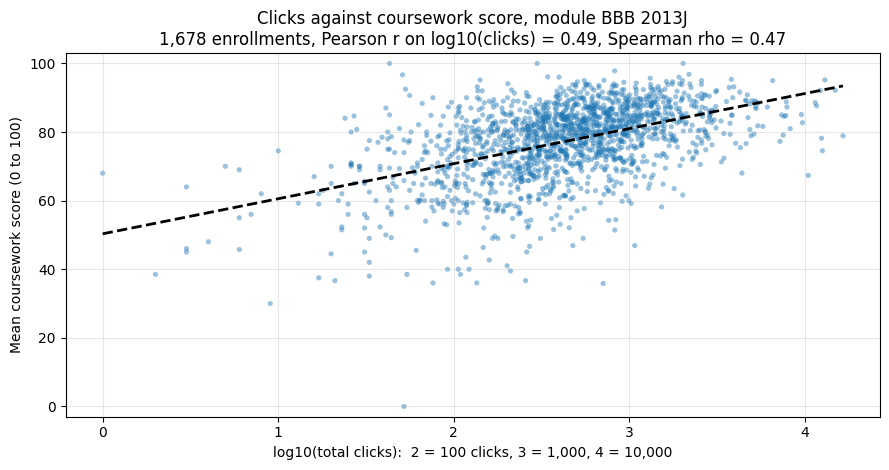

In [43]:
# EDIT THIS. Either '2013J' or '2014J'. It runs as written.
WHICH_PRESENTATION = '2013J'

# --- nothing below needs editing ---
if WHICH_PRESENTATION not in ('2013J', '2014J'):
    print(f'"{WHICH_PRESENTATION}" is not a presentation in this file. Using 2013J instead.')
    WHICH_PRESENTATION = '2013J'

q = build_panel(WHICH_PRESENTATION)
q_r_raw = q['total_clicks'].corr(q['mean_score'])
q_r_log = np.log10(q['total_clicks']).corr(q['mean_score'])
q_rho   = q['total_clicks'].corr(q['mean_score'], method='spearman')
n_enrolled = int((student_info['code_presentation'] == WHICH_PRESENTATION).sum())

print(f'Presentation          : {WHICH_PRESENTATION}')
print(f'Enrolled              : {n_enrolled:,}')
print(f'In the panel          : {len(q):,}')
print(f'Median clicks         : {q["total_clicks"].median():,.0f}')
print(f'Mean coursework score : {q["mean_score"].mean():.1f}')
print(f'Pearson r, raw clicks : {q_r_raw:.3f}')
print(f'Pearson r, log clicks : {q_r_log:.3f}')
print(f'Spearman rho          : {q_rho:.3f}')
print()
print('Assessments in this presentation:')
print(assessments[assessments['code_presentation'] == WHICH_PRESENTATION]
      [['assessment_type', 'date', 'weight']].to_string(index=False))
print()

# Comparing two years is comparing two estimates, so it needs an interval on the
# difference. Resample each year separately, take the gap, repeat 2,000 times.
a, b = build_panel('2013J'), build_panel('2014J')

def year_stats(df):
    x, y = df['total_clicks'].to_numpy(float), df['mean_score'].to_numpy(float)
    return x, np.log10(x), y

xa, la, ya = year_stats(a)
xb, lb, yb = year_stats(b)
rng = np.random.default_rng(8100)
d_rho, d_log = [], []
for _ in range(2000):
    s1 = rng.integers(0, len(a), len(a))
    s2 = rng.integers(0, len(b), len(b))
    d_rho.append(np.corrcoef(ranks(xa[s1]), ranks(ya[s1]))[0, 1]
                 - np.corrcoef(ranks(xb[s2]), ranks(yb[s2]))[0, 1])
    d_log.append(np.corrcoef(la[s1], ya[s1])[0, 1] - np.corrcoef(lb[s2], yb[s2])[0, 1])
ci_d_rho = np.percentile(d_rho, [2.5, 97.5])
ci_d_log = np.percentile(d_log, [2.5, 97.5])

rho_a = a['total_clicks'].corr(a['mean_score'], method='spearman')
rho_b = b['total_clicks'].corr(b['mean_score'], method='spearman')
log_a = np.log10(a['total_clicks']).corr(a['mean_score'])
log_b = np.log10(b['total_clicks']).corr(b['mean_score'])
print(f'2013J (n = {len(a):,}) against 2014J (n = {len(b):,}):')
print(f'  Spearman rho          {rho_a:.3f} vs {rho_b:.3f}, difference {rho_a - rho_b:.3f} '
      f'[{ci_d_rho[0]:.3f}, {ci_d_rho[1]:.3f}]')
print(f'  Pearson r, log clicks {log_a:.3f} vs {log_b:.3f}, difference {log_a - log_b:.3f} '
      f'[{ci_d_log[0]:.3f}, {ci_d_log[1]:.3f}]')
print('  Neither interval comes near zero, so the two years do differ. The data cannot tell')
print('  us why: the assessment structure differed too, so year and instrument are')
print('  confounded and this file cannot separate them.')
print()

pooled = pd.concat([build_panel('2013J'), build_panel('2014J')], ignore_index=True)
n_twice = int((pooled['id_student'].value_counts() == 2).sum())
print(f'And if you pooled the two years into one analysis: n = {len(pooled):,}, '
      f'Pearson r on log clicks = '
      f'{np.log10(pooled["total_clicks"]).corr(pooled["mean_score"]):.3f}, '
      f'Spearman rho = '
      f'{pooled["total_clicks"].corr(pooled["mean_score"], method="spearman"):.3f}')
print(f'Section 2a applies again: {n_twice} of those {len(pooled):,} rows are a student the other year')
print(f'already counted, so that estimate does not rest on {len(pooled):,} independent enrollments.')

fig, ax = plt.subplots(figsize=(9, 4.8))
xv = np.log10(q['total_clicks'])
ax.scatter(xv, q['mean_score'], s=14, color='#1f77b4', alpha=0.45, edgecolor='none')
s, i = np.polyfit(xv, q['mean_score'], 1)
xs = np.linspace(xv.min(), xv.max(), 100)
ax.plot(xs, s * xs + i, color='#000000', linewidth=2, linestyle='--')
ax.set_title(f'Clicks against coursework score, module BBB {WHICH_PRESENTATION}\n'
             f'{len(q):,} enrollments, Pearson r on log10(clicks) = {q_r_log:.2f}, '
             f'Spearman rho = {q_rho:.2f}')
ax.set_xlabel('log10(total clicks):  2 = 100 clicks, 3 = 1,000, 4 = 10,000')
ax.set_ylabel('Mean coursework score (0 to 100)')
ax.set_ylim(-3, 103)
plt.tight_layout()
plt.show()

### Let's discuss

1. Running it both ways gives, for each year, a Pearson `r` on log clicks and a Spearman rho.
   Would you describe them as the same finding? The printed interval on the difference is what
   allows an answer other than an impression: the two years differ by more than resampling
   variation explains, and the difference is larger on Spearman than the Pearson numbers alone
   indicated.
2. The mean coursework score differs substantially between the two years. Please read the
   assessment table printed above before explaining why. What changed about the course, and does
   that make the two years comparable at all? The interval is precise about *whether* the years
   differ and silent about *what* differs, because the year and the assessment structure changed
   together.
3. One module, two years, two answers. If they had been pooled into a single analysis, which of
   the two answers would have come out, and would the problem have been visible? The pooled row
   count is also not a count of people. How far off is it, and would that have changed anything?
4. Somebody asks what the relationship between activity and achievement is in module BBB. What
   would you say?

### Your turn 3: which clicks count as engagement?

`total_clicks` counts every click on every kind of resource: the forum, the homepage, quizzes,
PDFs, links out. Counting all of them is an analytic decision.

`vle.csv` labels every resource with an `activity_type`. You might choose the types you think
belong in an "engagement" indicator and re-run. Two things change: **how many enrollments are
excluded** because they have no recorded clicks on the types you chose, and the three-column table
of correlations. The middle column is the one to compare against. It is the all-types correlation
recomputed on the students your definition still includes, and without it there is no way to
distinguish a better feature from a smaller sample.

**Please run the cell below**, then edit the list and run it again.

In [44]:
# EDIT THIS LIST. It runs as written; the default keeps every activity type.
ACTIVITY_TYPES = ['forumng', 'homepage', 'quiz', 'subpage', 'resource',
                  'url', 'oucontent', 'glossary', 'oucollaborate', 'sharedsubpage']

# --- nothing below needs editing ---
sites = vle[vle['code_presentation'] == PRESENTATION][['id_site', 'activity_type']]
labeled = vle_log.merge(sites, on='id_site', how='left')

print('Clicks by activity type in this presentation:')
print(labeled.groupby('activity_type')['sum_click'].sum()
              .sort_values(ascending=False).map('{:,}'.format).to_string())
print()

chosen = [t for t in ACTIVITY_TYPES if t in set(labeled['activity_type'].dropna())]
if not chosen:
    print('None of those names matched an activity type. Using all of them instead.')
    chosen = sorted(labeled['activity_type'].dropna().unique().tolist())

kept = labeled[labeled['activity_type'].isin(chosen)]
feature = (kept.groupby('id_student')['sum_click'].sum()
               .rename('chosen_clicks').reset_index())

check = panel[['id_student', 'mean_score', 'total_clicks']].merge(feature, on='id_student',
                                                                 how='inner')
c_raw = check['chosen_clicks'].corr(check['mean_score'])
c_log = np.log10(check['chosen_clicks']).corr(check['mean_score'])
c_rho = check['chosen_clicks'].corr(check['mean_score'], method='spearman')

# The narrower definition also removes people, so a comparison against the full-panel
# number confuses two changes at once. Recompute the all-types number on whoever is left.
same_raw = check['total_clicks'].corr(check['mean_score'])
same_log = np.log10(check['total_clicks']).corr(check['mean_score'])
same_rho = check['total_clicks'].corr(check['mean_score'], method='spearman')

print(f'Counting: {", ".join(chosen)}')
print(f'Clicks kept   : {kept["sum_click"].sum():,} of {labeled["sum_click"].sum():,}')
print(f'Students left : {len(check):,} of {len(panel):,}   '
      f'({len(panel) - len(check)} excluded, with no recorded clicks on these resources)')
print()
print('                         your types   all types,      all types,')
print(f'                                      same students   all {len(panel):,}')
print(f'Pearson r, raw counts        {c_raw:.3f}         {same_raw:.3f}          {r_raw:.3f}')
print(f'Pearson r, log counts        {c_log:.3f}         {same_log:.3f}          {r_log:.3f}')
print(f'Spearman rho                 {c_rho:.3f}         {same_rho:.3f}          {rho:.3f}')
print()
print('The comparison to make is against the middle column, not the right one. The right column')
print('is computed on students your definition just removed, so a difference against it')
print('combines two changes at once: what you counted, and which students you could still count.')

Clicks by activity type in this presentation:
activity_type
forumng          702,326
homepage         344,964
quiz             118,688
subpage           81,487
resource          54,615
url               38,575
oucontent         34,877
glossary           1,916
oucollaborate      1,144
sharedsubpage         64

Counting: forumng, homepage, quiz, subpage, resource, url, oucontent, glossary, oucollaborate, sharedsubpage
Clicks kept   : 1,378,656 of 1,378,656
Students left : 1,678 of 1,678   (0 excluded, with no recorded clicks on these resources)

                         your types   all types,      all types,
                                      same students   all 1,678
Pearson r, raw counts        0.259         0.259          0.259
Pearson r, log counts        0.489         0.489          0.489
Spearman rho                 0.473         0.473          0.473

The comparison to make is against the middle column, not the right one. The right column
is computed on students your definition

**Let's discuss.** A definition changed, not a fact about any student, and the number a
dashboard would report about them changed with it.

The obvious comparison is your correlation against the 0.473 reported earlier, and that
comparison is confounded: your definition removed students, so any difference reflects both the
change in the feature and the change in the sample. The middle column is the cleaner comparison.
Whenever a new feature is announced as better than an old one, it is worth asking whether both
were measured on the same students.

It may be useful to write one sentence naming the candidate feature you would be willing to
defend if the student it describes were reading it, and one sentence about what is owed to the
students your definition excluded.

## Appendix: expected numbers for the Your turn cells

Please try each cell before reading these. They are here so that you can check your reading of
the output.

### Your turn 1: four cleaning decisions

The baseline setting, and four variations worth trying. The baseline sets banked scores aside,
which is the decision Section 5 made and recorded.

```python
INCLUDE_PRE_START_CLICKS = True  ; MIN_SUBMISSIONS = 1 ; KEEP_WITHDRAWN = True  ; KEEP_BANKED = False   # n = 1,678, Pearson 0.259 raw / 0.489 log, Spearman 0.473
INCLUDE_PRE_START_CLICKS = False ; MIN_SUBMISSIONS = 1 ; KEEP_WITHDRAWN = True  ; KEEP_BANKED = False   # n = 1,676, Pearson 0.256 raw / 0.481 log, Spearman 0.470
INCLUDE_PRE_START_CLICKS = True  ; MIN_SUBMISSIONS = 1 ; KEEP_WITHDRAWN = False ; KEEP_BANKED = False   # n = 1,481, Pearson 0.261 raw / 0.492 log, Spearman 0.473
INCLUDE_PRE_START_CLICKS = True  ; MIN_SUBMISSIONS = 3 ; KEEP_WITHDRAWN = True  ; KEEP_BANKED = False   # n = 1,491, Pearson 0.235 raw / 0.413 log, Spearman 0.411
INCLUDE_PRE_START_CLICKS = True  ; MIN_SUBMISSIONS = 1 ; KEEP_WITHDRAWN = True  ; KEEP_BANKED = True    # n = 1,697, Pearson 0.258 raw / 0.473 log, Spearman 0.466
```

What is worth noticing: the pre-start switch changes very little. It removes two enrollments and
moves the raw Pearson by three thousandths and the log Pearson by about eight thousandths. Dropping
withdrawn enrollments removes 197 rows and changes the estimates very little, which is itself a
result: once an enrollment has both recorded clicks and recorded coursework, the withdrawn label
adds little information. Putting the banked rows back adds 19 enrollments and moves the log Pearson
from 0.489 to 0.473, which is a small change and still worth seeing, because it is the one switch
that changes what a score *means* rather than which enrollments are counted.

Requiring three recorded submissions changes the estimated association much more than the other
choices: it removes 187 rows and takes the log Pearson from 0.489 to 0.413 and the Spearman from
0.473 to 0.411. It removes the enrollments with short records, which sit at the low end of the
association and account for much of it. The rank correlation, which is the least sensitive to the
shape you assume, changes least under the other switches: 0.473 at baseline against 0.470 and
0.473.

No single setting is the right one.

### Your turn 2: the other year

```python
WHICH_PRESENTATION = '2013J'   # n = 1,678, Pearson 0.259 raw / 0.489 log, Spearman 0.473, mean score 77.1
WHICH_PRESENTATION = '2014J'   # n = 1,788, Pearson 0.144 raw / 0.195 log, Spearman 0.106, mean score 64.3
```

What is worth noticing: the association in 2014J is well under half as strong on the log scale, and
the mean coursework score is about thirteen points lower. The assessment structure differs
substantially across the two presentations, so presentation year and assessment structure are
confounded here. 2013J ran six tutor-marked and five computer-marked assignments; 2014J ran five
tutor-marked assignments and one of those was weighted zero. This file does not allow us to
attribute the difference in correlations to either one, and it does not measure difficulty.

The two Spearman values differ by more than the two Pearson values do, not less: 0.47 against
0.11. The cell prints an interval on that difference rather than leaving you to judge it by eye,
because two numbers being printed as different is not the same as two estimates being different.
The difference in Spearman is about 0.37 with a 95 percent interval of roughly 0.30 to 0.43, and
the difference in the log Pearson is about 0.29 with an interval of roughly 0.22 to 0.37. Neither
interval is close to zero, so the years do differ.

That establishes *whether* the years differ and says nothing about *why*. An interval is precise
about sampling variation and silent about confounding.

Pool the two years into one analysis and the Pearson on log clicks comes out near 0.23 and the
Spearman near 0.15, which is lower than 2013J, higher than 2014J, and an accurate description of
neither year. In addition, 23 of the 3,466 pooled rows are a student the other year already
counted, so the pooled analysis does not rest on 3,466 independent enrollments either. That is the
argument for keeping the presentations apart, and it is why "we analyzed module BBB" is not an
adequate methods sentence.

### Your turn 3: which clicks count

```python
ACTIVITY_TYPES = ['forumng']                       # log Pearson 0.405, Spearman 0.420,  71 enrollments excluded
ACTIVITY_TYPES = ['quiz']                          # log Pearson 0.384, Spearman 0.312,  92 enrollments excluded
ACTIVITY_TYPES = ['oucontent']                     # log Pearson 0.417, Spearman 0.395, 188 enrollments excluded
ACTIVITY_TYPES = ['forumng', 'quiz', 'oucontent']  # log Pearson 0.480, Spearman 0.469,  14 enrollments excluded
ACTIVITY_TYPES = ['homepage']                      # log Pearson 0.470, Spearman 0.455,   1 enrollment excluded
```

What is worth noticing, and the order of comparison matters. Please compare each of those against
the **middle** column the cell prints, which is the all-types correlation recomputed on the students
your definition still includes, rather than against the 0.473 from the full panel. On that
comparison no single activity type does better than counting everything: forum 0.405 against 0.454
on the same 1,607 students, quiz 0.384 against 0.425 on the same 1,586, course material 0.417
against 0.451 on the same 1,490. The three combined are the one candidate that does do better, 0.480
against 0.467 on the same 1,664, and the accurate description is a slightly higher correlation
measured on nearly the whole panel, rather than a better feature.

The narrower the definition, the more enrollments it excludes. `oucontent`, the actual course
material, excludes 201 enrollments that have no click on that type recorded in the log. A feature
that removes nearly two hundred students without saying so is not a neutral measurement choice, and
it is the reason the middle column exists: without it, a feature could appear better simply by
discarding the students it fits worst.

It is also worth noticing that `quiz` clicks are close to forum clicks on Pearson and clearly lower
on Spearman, 0.31 against 0.42. The two statistics rank these candidate features differently, and
which of them gets reported is a choice, made either before or after seeing the numbers. Then there
is the question of whether "clicking a quiz" is an indicator of engagement or an indicator of *being
assessed*, and whether a dashboard built on quiz clicks is measuring the student or the assessment
schedule.